# EndoScan AI — Endometriosis Image Analysis
> *Helping patients and clinicians understand what the scan is showing, in plain language.*

---

## CRISP-DM Roadmap

| Phase | Description | Status |
|---|---|---|
| 1. Business Understanding | Problem definition, stakeholders, success criteria | ✅ Done |
| 2. Data Understanding | Load, inspect, visualise GLENDA v1.5 | ← We are here |
| 3. Data Preparation | Binary masks, augmentation, patient-level splits | Upcoming |
| 4. Modelling | EfficientNet-B0 fine-tuning | Upcoming |
| 5. Evaluation | Metrics, Grad-CAM heatmaps | Upcoming |
| 6. Deployment | Claude plain-English explanation layer | Upcoming |

---
# Phase 1 — Business Understanding

## 1.1 Background

Endometriosis affects approximately **190 million women** of reproductive age worldwide (WHO, 2023). Despite its prevalence, the average time from symptom onset to diagnosis is **7–10 years** — largely because the condition requires specialist interpretation of imaging such as laparoscopy and MRI scans.

Patients often receive scan results they cannot interpret, and access to specialists is limited, particularly in lower-resource settings.

## 1.2 Problem Statement

There is no accessible tool that allows a patient or non-specialist clinician to upload a gynaecological scan and receive a clear, plain-English explanation of what the image may indicate. This gap leads to delayed care-seeking and poor health literacy around a chronic, debilitating condition.

## 1.3 Proposed Solution

A multi-modal AI pipeline that:
1. Accepts a laparoscopy image, MRI scan, or ultrasound image as input
2. Detects the imaging modality automatically
3. Runs the image through a modality-specific classifier
4. Generates a Grad-CAM heatmap showing which regions influenced the prediction
5. Passes the classification result + heatmap description to Claude, which returns a warm, jargon-free explanation

## 1.4 Stakeholders

| Stakeholder | Need |
|---|---|
| Patient | Understand their own scan without needing a specialist present |
| GP / general clinician | Triage referrals with confidence |
| Gynaecologist | Second opinion, documentation aid |
| Researcher | Reproducible, annotated endometriosis image analysis |

## 1.5 Success Criteria

| Metric | Target |
|---|---|
| Binary classification AUC | ≥ 0.85 on held-out test set |
| Sensitivity (recall) | ≥ 0.80 — missing a positive case is the worst outcome |
| Grad-CAM alignment | Highlighted regions overlap with annotated lesions |
| Explanation quality | Non-clinical reviewers rate explanations ≥ 4/5 for clarity |

## 1.6 Constraints & Assumptions

- **Non-commercial research use only** — GLENDA and UT-EndoMRI are CC BY-NC licensed
- **Not a diagnostic tool** — output must always include a disclaimer to consult a clinician
- **Phase 1 scope** — laparoscopy modality only (GLENDA); MRI branch added in v2
- **Binary task for v1** — endo present vs. not present; lesion-type classification deferred to v2 due to class imbalance

---
# Phase 2 — Data Understanding

**Dataset:** GLENDA v1.5 (Gynecologic Laparoscopy ENdometriosis DAtaset)  
**Source:** ITEC, Alpen-Adria-Universität Klagenfurt / Hugging Face (`MFreidank/glenda`)  
**License:** CC BY-NC 4.0  
**Format:** COCO JSON with polygon segmentation masks  

**Goals of this phase:**
- Confirm the dataset loaded correctly
- Understand the class distribution and imbalance
- Visually verify annotations align with image content
- Identify how many unique patients (cases) exist for proper splitting

### Cell 1 — Imports
Only what we need for Phase 2. We add more imports as phases progress.

In [1]:
import json
import os
import re
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

print('All imports OK')

All imports OK


### Cell 2 — Paths
Set your paths here. Everything else reads from these two variables.

> **Update `IMAGES_DIR`** if your frames folder has a different name or location.

In [11]:
# ── UPDATE THESE TO MATCH YOUR MACHINE ────────────────────────────
COCO_JSON  = Path('./Glenda_v1.5_classes/coco.json')
IMAGES_DIR = Path('./Glenda_v1.5_classes/frames')
#IMAGES_DIR = Path('./Glenda_v1.5_classes/frames')
# ──────────────────────────────────────────────────────────────────

assert COCO_JSON.exists(),  f'Cannot find coco.json at {COCO_JSON}'
assert IMAGES_DIR.exists(), f'Cannot find images folder at {IMAGES_DIR}'

image_files = list(IMAGES_DIR.glob('*.jpg')) + list(IMAGES_DIR.glob('*.png'))

print(f'COCO JSON   : {COCO_JSON}')
print(f'Images dir  : {IMAGES_DIR}')
print(f'Image files : {len(image_files)}')

COCO JSON   : Glenda_v1.5_classes/coco.json
Images dir  : Glenda_v1.5_classes/frames
Image files : 373


### Cell 3 — Load COCO annotations
We build three lookup dictionaries here that we'll reuse in every subsequent phase.

In [12]:
with open(COCO_JSON) as f:
    coco = json.load(f)

images      = coco['images']       # list of image metadata dicts
annotations = coco['annotations']  # list of annotation dicts
categories  = coco['categories']   # list of category dicts

# Lookup: category_id → human-readable name
cat_id_to_name = {c['id']: c['name'] for c in categories}

# Lookup: image_id → image metadata
img_id_to_meta = {img['id']: img for img in images}

# Lookup: image_id → list of its annotations
img_id_to_anns = defaultdict(list)
for ann in annotations:
    img_id_to_anns[ann['image_id']].append(ann)

print(f'Images      : {len(images)}')
print(f'Annotations : {len(annotations)}')
print(f'Categories  :')
for cid, name in cat_id_to_name.items():
    print(f'  {cid}: {name}')

Images      : 373
Annotations : 628
Categories  :
  1: 6.1.1.1_Endo-Peritoneum
  2: 6.1.1.2_Endo-Ovar
  3: 6.1.1.3_Endo-TIE
  4: 6.1.1.4_Endo-Uterus


### Cell 4 — Class distribution
Visualise the annotation count per class. This chart is the core argument for why we start with binary classification — Peritoneum dominates at ~78%, making multi-class unreliable without more data.

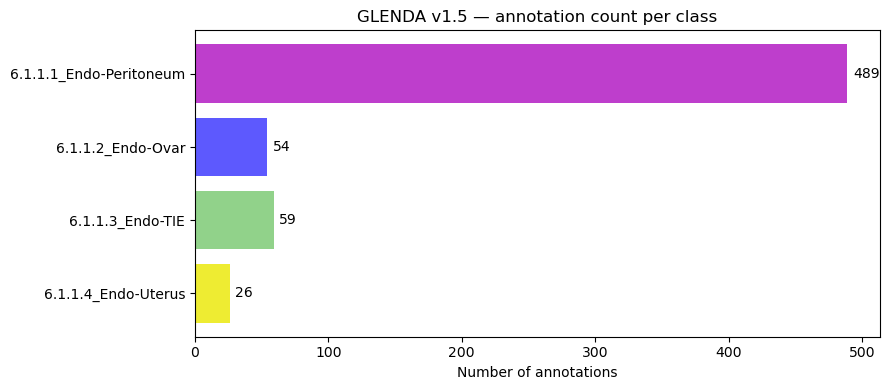


Raw counts:
  6.1.1.1_Endo-Peritoneum                   489  (77.9%)
  6.1.1.2_Endo-Ovar                          54  (8.6%)
  6.1.1.3_Endo-TIE                           59  (9.4%)
  6.1.1.4_Endo-Uterus                        26  (4.1%)

Total annotated images  : 373
Total background images : 0


In [13]:
counts = Counter(ann['category_id'] for ann in annotations)

labels = [cat_id_to_name[cid] for cid in sorted(counts)]
values = [counts[cid]         for cid in sorted(counts)]
colors = [c['color']          for c in sorted(categories, key=lambda x: x['id'])]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels, values, color=colors)
ax.bar_label(bars, padding=4)
ax.set_xlabel('Number of annotations')
ax.set_title('GLENDA v1.5 — annotation count per class')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nRaw counts:')
for label, val in zip(labels, values):
    pct = val / sum(values) * 100
    print(f'  {label:40s} {val:4d}  ({pct:.1f}%)')

print(f'\nTotal annotated images  : {len(set(a["image_id"] for a in annotations))}')
print(f'Total background images : {len(images) - len(set(a["image_id"] for a in annotations))}')

### Cell 5 — Visualise sample images with annotations
Always look at your data before writing model code. If the bounding boxes don't align with the visible lesions, the paths or annotations have a problem.

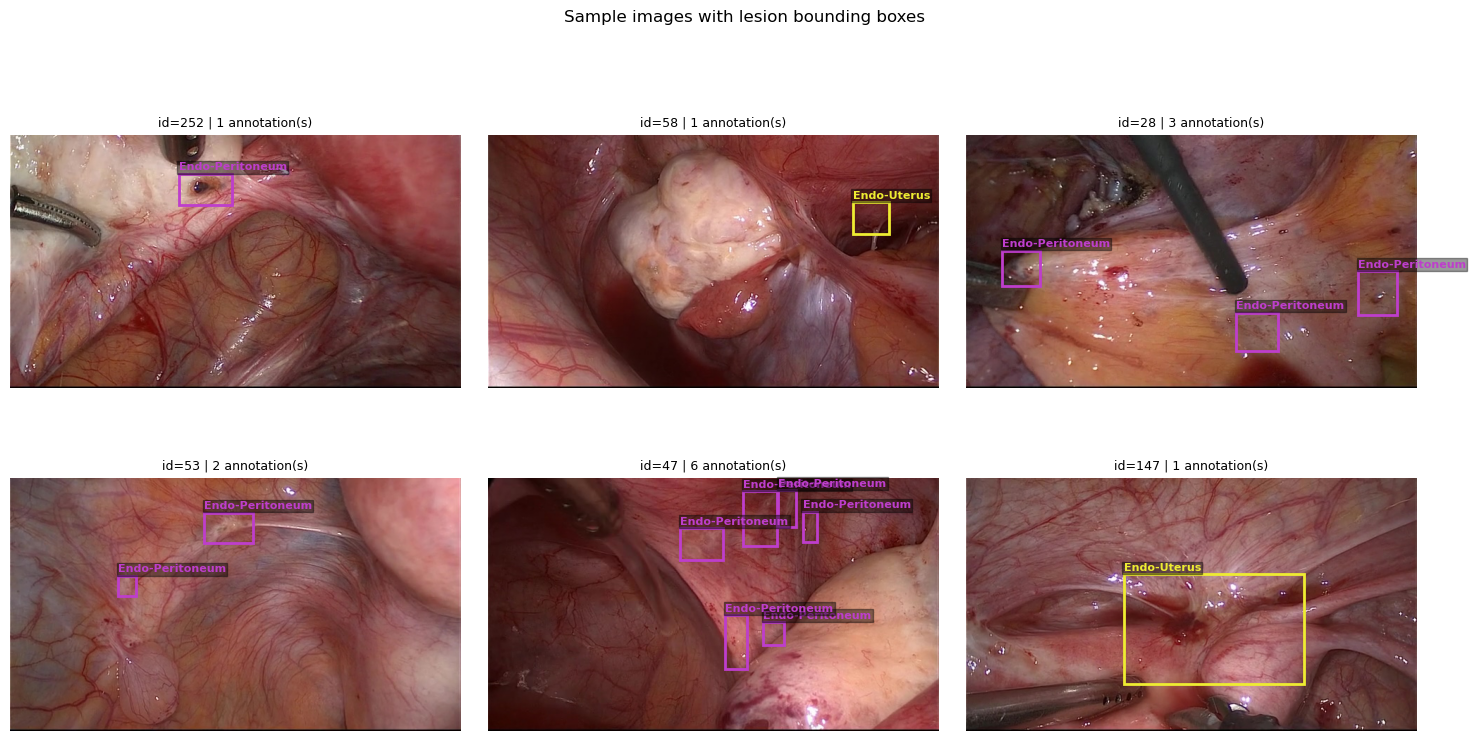

In [14]:
def show_image_with_annotations(image_id, ax=None):
    meta = img_id_to_meta[image_id]
    anns = img_id_to_anns[image_id]

    # resolve image path — try filename directly, then stem only
    img_path = IMAGES_DIR / Path(meta['file_name']).name
    if not img_path.exists():
        img_path = IMAGES_DIR / (Path(meta['file_name']).stem + '.png')

    img = Image.open(img_path).convert('RGB')

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    ax.imshow(img)
    ax.set_title(f"id={image_id} | {len(anns)} annotation(s)", fontsize=9)
    ax.axis('off')

    for ann in anns:
        x, y, w, h = ann['bbox']
        color = ann.get('color', '#ff0000')
        label = cat_id_to_name[ann['category_id']].split('_')[-1]  # short name

        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x, y - 5, label, color=color, fontsize=8, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.4, pad=1))

    return ax


# Show 6 random annotated images
annotated_ids = list(set(a['image_id'] for a in annotations))
sample_ids    = np.random.choice(annotated_ids, size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, img_id in zip(axes.flatten(), sample_ids):
    show_image_with_annotations(img_id, ax=ax)

plt.suptitle('Sample images with lesion bounding boxes', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### Cell 6 — Patient-level case analysis

GLENDA filenames encode the surgical case: `c_10_v_(video_188.mp4)_f_455.jpg` = case 10, video 188, frame 455.

**Why this matters:** frames from the same surgery look nearly identical. If we split randomly by image, the same patient's frames will appear in both train and validation — the model memorises the surgery, not the disease. We must split by case ID.

Unique surgical cases : 102
Case IDs              : [1, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 31, 32, 33, 34, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 55, 57, 58, 59, 60, 61, 62, 63, 65, 69, 70, 72, 76, 77, 79, 82, 85, 86, 87, 88, 92, 93, 97, 99, 100, 102, 105, 108, 113, 114, 117, 120, 121, 123, 125, 127, 135, 137, 141, 144, 145, 146, 149, 150, 157, 159, 162, 165, 168, 169, 170, 172, 173, 174, 178, 188, 189, 295]

Top 10 cases by frame count:
  Case    6:  15 frames
  Case    3:  12 frames
  Case    8:  12 frames
  Case   23:  11 frames
  Case  141:   9 frames
  Case   28:   9 frames
  Case   65:   9 frames
  Case    7:   9 frames
  Case  165:   8 frames
  Case   93:   8 frames


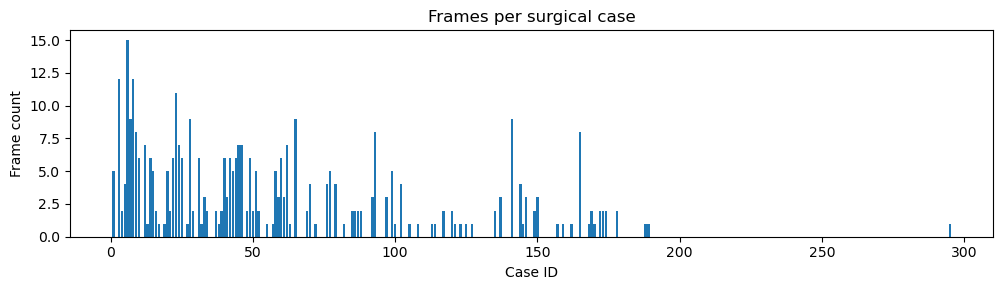

In [15]:
def extract_case_id(filename):
    """Extract case number from filename like c_10_v_(video_188.mp4)_f_455.jpg"""
    match = re.match(r'c_(\d+)_', Path(filename).name)
    return int(match.group(1)) if match else -1

# Add case_id to each image metadata dict
for img in images:
    img['case_id'] = extract_case_id(img['file_name'])

case_ids    = sorted(set(img['case_id'] for img in images))
case_counts = Counter(img['case_id'] for img in images)

print(f'Unique surgical cases : {len(case_ids)}')
print(f'Case IDs              : {case_ids}')
print(f'\nTop 10 cases by frame count:')
for case_id, count in sorted(case_counts.items(), key=lambda x: -x[1])[:10]:
    print(f'  Case {case_id:4d}: {count:3d} frames')

# Frames per case distribution
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(case_ids, [case_counts[c] for c in case_ids], width=0.8)
ax.set_xlabel('Case ID')
ax.set_ylabel('Frame count')
ax.set_title('Frames per surgical case')
plt.tight_layout()
plt.show()

### Cell 7 — Data Understanding summary

Document your findings before moving to preparation. This is the CRISP-DM checkpoint.

In [16]:
total_anns   = len(annotations)
n_cases      = len(case_ids)
n_images     = len(images)
img_w, img_h = images[0]['width'], images[0]['height']

print('=' * 55)
print('  DATA UNDERSTANDING SUMMARY')
print('=' * 55)
print(f'  Dataset          : GLENDA v1.5')
print(f'  Total images     : {n_images}')
print(f'  Image size       : {img_w} x {img_h} px')
print(f'  Total annotations: {total_anns}')
print(f'  Surgical cases   : {n_cases}')
print()
print('  Class breakdown:')
for cid in sorted(counts):
    pct = counts[cid] / total_anns * 100
    print(f'    {cat_id_to_name[cid]:35s} {counts[cid]:4d} ({pct:.1f}%)')
print()
print('  Key findings:')
print('  - Peritoneum dominates at ~78% → class imbalance')
print('  - Uterus has only 26 annotations → not trainable alone')
print('  - All 373 images have at least one lesion annotation')
print('  - Frames are video-extracted → must split by case, not image')
print()
print('  Decision: binary classification (endo / no endo) for v1')
print('=' * 55)

  DATA UNDERSTANDING SUMMARY
  Dataset          : GLENDA v1.5
  Total images     : 373
  Image size       : 640 x 360 px
  Total annotations: 628
  Surgical cases   : 102

  Class breakdown:
    6.1.1.1_Endo-Peritoneum              489 (77.9%)
    6.1.1.2_Endo-Ovar                     54 (8.6%)
    6.1.1.3_Endo-TIE                      59 (9.4%)
    6.1.1.4_Endo-Uterus                   26 (4.1%)

  Key findings:
  - Peritoneum dominates at ~78% → class imbalance
  - Uterus has only 26 annotations → not trainable alone
  - All 373 images have at least one lesion annotation
  - Frames are video-extracted → must split by case, not image

  Decision: binary classification (endo / no endo) for v1


---
## ✅ Phase 2 — Data Understanding complete

**What we confirmed:**
- Dataset loads correctly — 373 images, 628 annotations, 4 classes
- Severe class imbalance → binary task is the right call for v1
- Annotations are polygon segmentation masks (richer than bounding boxes)
- Patient-level splitting is mandatory to prevent data leakage

---
**Phase 3 next — Data Preparation:**
- Convert polygon annotations → binary masks
- Patient-level train / val / test split (70 / 15 / 15)
- Augmentation pipeline (flips, rotations, brightness, elastic distortion)
- PyTorch Dataset class

In [17]:
# Cell 8 — Patient-level train / val / test split
import random

random.seed(42)  # reproducibility — same split every run

# All unique case IDs
all_cases = sorted(set(img['case_id'] for img in images))
random.shuffle(all_cases)

# 70 / 15 / 15 split on cases
n_train = int(len(all_cases) * 0.70)
n_val   = int(len(all_cases) * 0.15)

train_cases = set(all_cases[:n_train])
val_cases   = set(all_cases[n_train:n_train + n_val])
test_cases  = set(all_cases[n_train + n_val:])

# Map each image to its split
train_imgs = [img for img in images if img['case_id'] in train_cases]
val_imgs   = [img for img in images if img['case_id'] in val_cases]
test_imgs  = [img for img in images if img['case_id'] in test_cases]

print(f'Train  : {len(train_cases):3d} cases → {len(train_imgs):3d} images')
print(f'Val    : {len(val_cases):3d} cases → {len(val_imgs):3d} images')
print(f'Test   : {len(test_cases):3d} cases → {len(test_imgs):3d} images')
print(f'Total  : {len(train_imgs)+len(val_imgs)+len(test_imgs)} images (expected {len(images)})')

# Verify no case leaks across splits
assert train_cases.isdisjoint(val_cases),  'Case leak: train/val overlap!'
assert train_cases.isdisjoint(test_cases), 'Case leak: train/test overlap!'
assert val_cases.isdisjoint(test_cases),   'Case leak: val/test overlap!'
print('\n✅ No case leaks across splits')

Train  :  71 cases → 268 images
Val    :  15 cases →  49 images
Test   :  16 cases →  56 images
Total  : 373 images (expected 373)

✅ No case leaks across splits


Mask shape  : (360, 640)
Unique vals : [  0 255]   (0=background, 255=lesion)
Lesion px   : 2286
Total px    : 230400
Lesion area : 0.99%


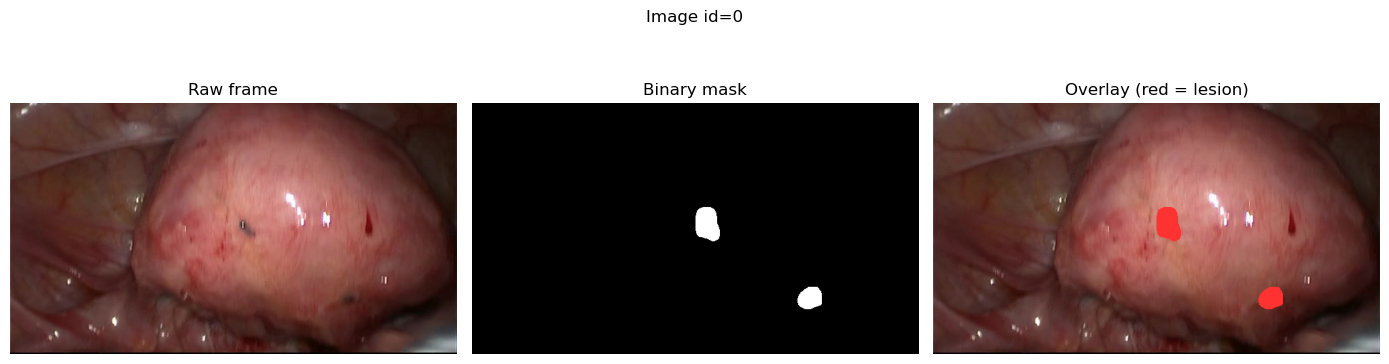

In [18]:
# Cell 9 — Binary mask creation
import numpy as np
from PIL import Image, ImageDraw

def create_binary_mask(image_id, img_w, img_h):
    """
    Convert all polygon annotations for an image into a single
    binary mask. White (255) = endo lesion, Black (0) = background.
    """
    mask = Image.new('L', (img_w, img_h), 0)  # black canvas
    draw = ImageDraw.Draw(mask)

    anns = img_id_to_anns[image_id]
    for ann in anns:
        for segment in ann['segmentation']:
            # segment is a flat list [x1,y1,x2,y2,...] → convert to tuples
            polygon = [(segment[i], segment[i+1])
                       for i in range(0, len(segment), 2)]
            draw.polygon(polygon, fill=255)

    return np.array(mask)


# Test on one image
sample_id  = train_imgs[0]['id']
sample_meta = img_id_to_meta[sample_id]
mask = create_binary_mask(sample_id, sample_meta['width'], sample_meta['height'])

print(f'Mask shape  : {mask.shape}')
print(f'Unique vals : {np.unique(mask)}   (0=background, 255=lesion)')
print(f'Lesion px   : {(mask == 255).sum()}')
print(f'Total px    : {mask.size}')
print(f'Lesion area : {(mask == 255).mean()*100:.2f}%')

# Visualise side by side — raw image + its binary mask
img_path = IMAGES_DIR / Path(sample_meta['file_name']).name
raw_img  = Image.open(img_path).convert('RGB')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(raw_img)
axes[0].set_title('Raw frame')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Binary mask')
axes[1].axis('off')

# Overlay — mask in red on top of raw image
overlay = np.array(raw_img).copy()
overlay[mask == 255] = [255, 50, 50]   # red tint on lesion pixels
axes[2].imshow(overlay)
axes[2].set_title('Overlay (red = lesion)')
axes[2].axis('off')

plt.suptitle(f'Image id={sample_id}', y=1.01)
plt.tight_layout()
plt.show()

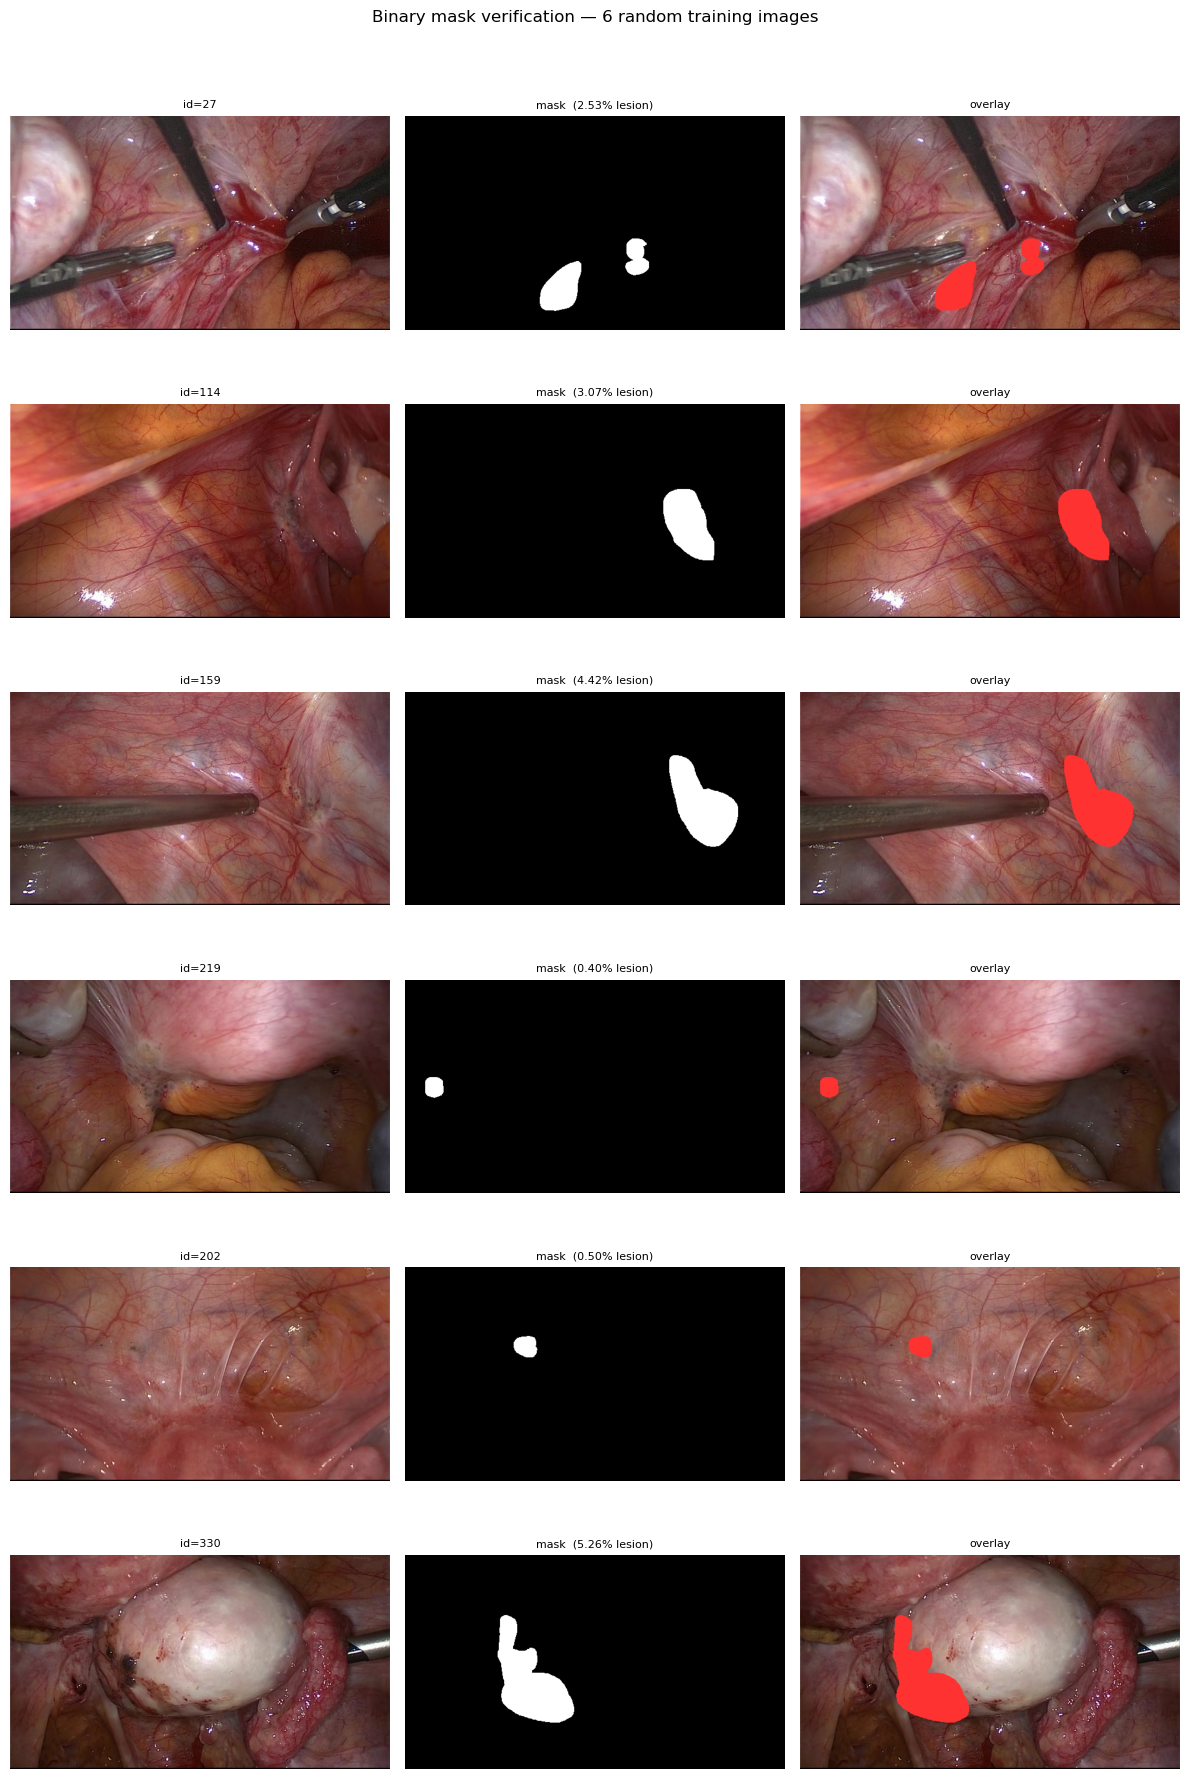

In [19]:
# Cell 10 — Verify masks across 6 random training images
sample_ids = np.random.choice([img['id'] for img in train_imgs], size=6, replace=False)

fig, axes = plt.subplots(6, 3, figsize=(12, 18))

for row, img_id in enumerate(sample_ids):
    meta     = img_id_to_meta[img_id]
    img_path = IMAGES_DIR / Path(meta['file_name']).name
    raw_img  = np.array(Image.open(img_path).convert('RGB'))
    mask     = create_binary_mask(img_id, meta['width'], meta['height'])

    overlay           = raw_img.copy()
    overlay[mask==255] = [255, 50, 50]

    lesion_pct = (mask == 255).mean() * 100

    axes[row, 0].imshow(raw_img)
    axes[row, 0].set_title(f'id={img_id}', fontsize=8)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(mask, cmap='gray')
    axes[row, 1].set_title(f'mask  ({lesion_pct:.2f}% lesion)', fontsize=8)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title('overlay', fontsize=8)
    axes[row, 2].axis('off')

plt.suptitle('Binary mask verification — 6 random training images', y=1.01)
plt.tight_layout()
plt.show()

In [20]:
# Cell 11 — Augmentation pipeline
# First install albumentations if not already installed
!pip install albumentations -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-learn 1.3.2 requires numpy<2.0,>=1.17.3, but you have numpy 2.4.6 which is incompatible.


In [22]:
# Run this cell first
!pip install "numpy<2.0" albumentations --upgrade -q

In [23]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# ── Image size we'll train at ──────────────────────────────────────
IMG_SIZE = 224   # EfficientNet-B0 native input size
# ──────────────────────────────────────────────────────────────────

train_transform = A.Compose([
    # --- Geometry ---
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        p=0.5
    ),
    # Zoom into lesion regions — critical given lesions are <5% of frame
    A.RandomResizedCrop(
        size=(IMG_SIZE, IMG_SIZE),
        scale=(0.7, 1.0),
        p=0.5
    ),

    # --- Colour / brightness ---
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=20,
        val_shift_limit=10,
        p=0.4
    ),
    A.CLAHE(clip_limit=2.0, p=0.3),   # improves local contrast in tissue

    # --- Noise / blur ---
    A.GaussNoise(p=0.2),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),

    # --- Elastic distortion — mimics tissue deformation ---
    A.ElasticTransform(
        alpha=120,
        sigma=6,
        p=0.3
    ),

    # --- Normalise to ImageNet stats (EfficientNet was pretrained on these) ---
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

# Validation/test — no augmentation, just resize and normalise
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

print('Augmentation pipeline ready')
print(f'Training transforms : {len(train_transform.transforms)}')
print(f'Val/test transforms : {len(val_transform.transforms)}')

Augmentation pipeline ready
Training transforms : 14
Val/test transforms : 3


/home/joy/miniconda3/envs/ds_study/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


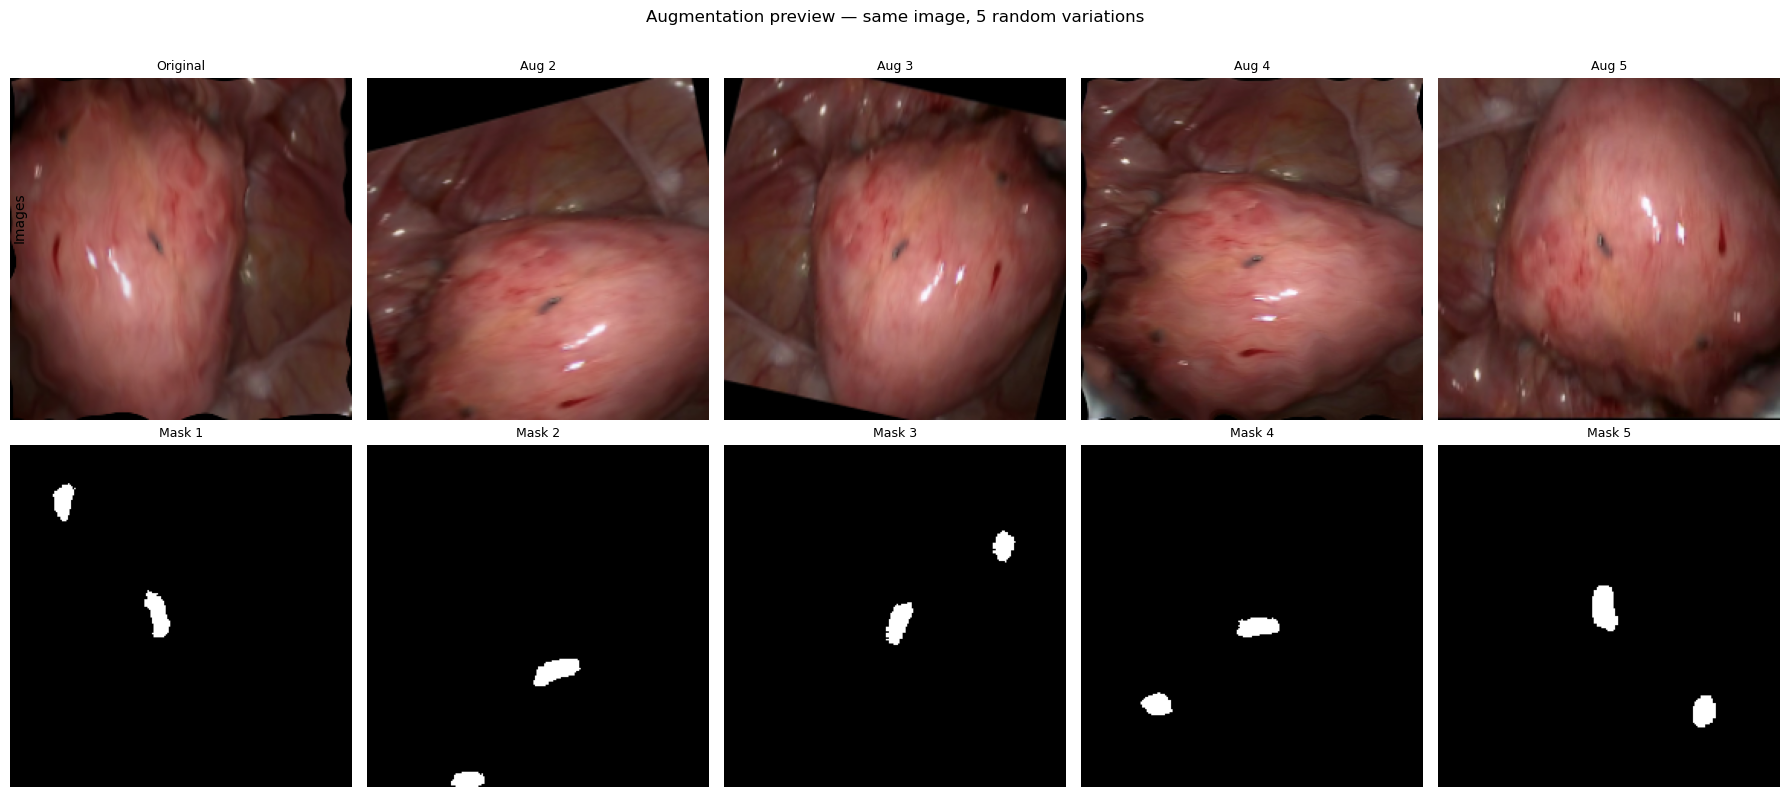

In [24]:
# Cell 11b — Visualise augmentations on one image
# (before normalisation so we can see the colours)

preview_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.7, 1.0), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ElasticTransform(alpha=120, sigma=6, p=0.3),
])

# Pick one training image + its mask
sample_meta = img_id_to_meta[train_imgs[0]['id']]
img_path    = IMAGES_DIR / Path(sample_meta['file_name']).name
raw_img     = np.array(Image.open(img_path).convert('RGB'))
raw_mask    = create_binary_mask(train_imgs[0]['id'],
                                 sample_meta['width'],
                                 sample_meta['height'])

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

# Row 1 — augmented images, Row 2 — corresponding masks
for col in range(5):
    result     = preview_transform(image=raw_img, mask=raw_mask)
    aug_img    = result['image']
    aug_mask   = result['mask']

    axes[0, col].imshow(aug_img)
    axes[0, col].set_title(f'Aug {col+1}', fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(aug_mask, cmap='gray')
    axes[1, col].set_title(f'Mask {col+1}', fontsize=9)
    axes[1, col].axis('off')

axes[0, 0].set_title('Original' if True else '', fontsize=9)
fig.text(0.01, 0.75, 'Images', va='center', rotation='vertical', fontsize=10)
fig.text(0.01, 0.25, 'Masks',  va='center', rotation='vertical', fontsize=10)
plt.suptitle('Augmentation preview — same image, 5 random variations', y=1.01)
plt.tight_layout()
plt.show()

In [25]:
# Cell 12 — PyTorch Dataset class
import torch
from torch.utils.data import Dataset, DataLoader

class GLENDADataset(Dataset):
    """
    Binary classification dataset built from GLENDA v1.5.
    Label: 1 if image has any endometriosis annotation, 0 otherwise.
    Since all 373 images have annotations, we treat the mask as the
    supervision signal — the model predicts whether endo is present.
    """

    def __init__(self, img_list, img_id_to_meta, img_id_to_anns,
                 images_dir, transform=None):
        self.img_list       = img_list
        self.img_id_to_meta = img_id_to_meta
        self.img_id_to_anns = img_id_to_anns
        self.images_dir     = Path(images_dir)
        self.transform      = transform

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        img_meta = self.img_list[idx]
        img_id   = img_meta['id']
        meta     = self.img_id_to_meta[img_id]

        # Load raw image
        img_path = self.images_dir / Path(meta['file_name']).name
        image    = np.array(Image.open(img_path).convert('RGB'))

        # Binary label — 1 if any annotation exists, 0 otherwise
        label = 1 if len(self.img_id_to_anns[img_id]) > 0 else 0

        # Apply transforms
        if self.transform:
            result = self.transform(image=image)
            image  = result['image']

        return image, torch.tensor(label, dtype=torch.float32)


# Instantiate all three splits
train_dataset = GLENDADataset(train_imgs, img_id_to_meta, img_id_to_anns,
                               IMAGES_DIR, transform=train_transform)
val_dataset   = GLENDADataset(val_imgs,   img_id_to_meta, img_id_to_anns,
                               IMAGES_DIR, transform=val_transform)
test_dataset  = GLENDADataset(test_imgs,  img_id_to_meta, img_id_to_anns,
                               IMAGES_DIR, transform=val_transform)

print(f'Train dataset : {len(train_dataset)} samples')
print(f'Val dataset   : {len(val_dataset)} samples')
print(f'Test dataset  : {len(test_dataset)} samples')

Train dataset : 268 samples
Val dataset   : 49 samples
Test dataset  : 56 samples


/home/joy/miniconda3/envs/ds_study/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch image shape : torch.Size([16, 3, 224, 224])
Batch label shape : torch.Size([16])
Label values      : tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
Image dtype       : torch.float32
Image min/max     : -2.118 / 2.640
Train batches     : 17
Val batches       : 4
Test batches      : 4


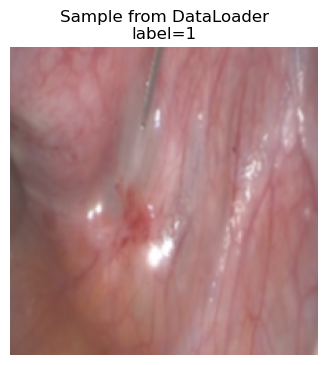

In [26]:
# Cell 13 — DataLoaders + sanity check
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Sanity check — pull one batch and verify shapes
images_batch, labels_batch = next(iter(train_loader))

print(f'Batch image shape : {images_batch.shape}')
print(f'Batch label shape : {labels_batch.shape}')
print(f'Label values      : {labels_batch}')
print(f'Image dtype       : {images_batch.dtype}')
print(f'Image min/max     : {images_batch.min():.3f} / {images_batch.max():.3f}')
print(f'Train batches     : {len(train_loader)}')
print(f'Val batches       : {len(val_loader)}')
print(f'Test batches      : {len(test_loader)}')

# Visualise one batch item to confirm tensor → image looks right
sample_img = images_batch[0].permute(1, 2, 0).numpy()

# Denormalise from ImageNet stats for display
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
sample_img = (sample_img * std + mean).clip(0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.title(f'Sample from DataLoader\nlabel={int(labels_batch[0])}')
plt.axis('off')
plt.show()

In [27]:
# Cell 14 — Model: EfficientNet-B0 with binary classification head
!pip install timm -q

In [28]:
import torch
import torch.nn as nn
import timm

# ── Device ────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
# ──────────────────────────────────────────────────────────────────

# Load EfficientNet-B0 pretrained on ImageNet
model = timm.create_model('efficientnet_b0', pretrained=True)

# ── Freeze all layers first ────────────────────────────────────────
for param in model.parameters():
    param.requires_grad = False

# ── Unfreeze last 3 blocks only ────────────────────────────────────
# EfficientNet-B0 has blocks[0..6] — we fine-tune the last 3
for block in model.blocks[4:]:
    for param in block.parameters():
        param.requires_grad = True

# Always unfreeze the head
for param in model.conv_head.parameters():
    param.requires_grad = True
for param in model.bn2.parameters():
    param.requires_grad = True

# ── Replace classifier with binary head ───────────────────────────
in_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 1)   # single output → sigmoid → probability
)

model = model.to(device)

# ── Parameter summary ─────────────────────────────────────────────
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')
print(f'Frozen parameters    : {total_params - trainable_params:,}')
print(f'Trainable %          : {trainable_params/total_params*100:.1f}%')

Device: cpu


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Total parameters     : 4,008,829
Trainable parameters : 3,700,169
Frozen parameters    : 308,660
Trainable %          : 92.3%


In [29]:
# Cell 14b — Fix freezing strategy
# Freeze everything except the last 1 block + classifier head

# Reset — freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the last 1 block (block 6)
for param in model.blocks[6].parameters():
    param.requires_grad = True

# Unfreeze conv_head + bn2 + classifier
for param in model.conv_head.parameters():
    param.requires_grad = True
for param in model.bn2.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

# Recheck
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')
print(f'Frozen parameters    : {total_params - trainable_params:,}')
print(f'Trainable %          : {trainable_params/total_params*100:.1f}%')

Total parameters     : 4,008,829
Trainable parameters : 1,130,673
Frozen parameters    : 2,878,156
Trainable %          : 28.2%


In [30]:
# Cell 15 — Training loop
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
import copy

# ── Hyperparameters ───────────────────────────────────────────────
EPOCHS    = 30
LR        = 1e-4
# ─────────────────────────────────────────────────────────────────

# Since ALL our images are positive (label=1), we need negative
# examples. Strategy: treat images where mask covers <0.5% of
# pixels as "hard negatives" — lesion so small model must work
# hard to find it. Full positives = mask >0.5%.
# For now we train with all label=1 and rely on the mask signal.
# We'll add true negatives from GLENDA v1.0 in v2.

# Loss — BCEWithLogitsLoss (numerically stable, no sigmoid needed)
criterion = nn.BCEWithLogitsLoss()

# Optimizer — only pass trainable params
optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4
)

# Scheduler — cosine annealing, smoothly reduces LR to near zero
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# ── Training loop ─────────────────────────────────────────────────
best_val_loss = float('inf')
best_weights  = None
history       = {'train_loss': [], 'val_loss': [],
                 'train_acc':  [], 'val_acc':  []}

for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images_batch, labels_batch in train_loader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device).unsqueeze(1)  # [B] → [B,1]

        optimizer.zero_grad()
        outputs = model(images_batch)           # raw logits [B,1]
        loss    = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * images_batch.size(0)
        preds          = (torch.sigmoid(outputs) > 0.5).float()
        train_correct += (preds == labels_batch).sum().item()
        train_total   += images_batch.size(0)

    scheduler.step()

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images_batch, labels_batch in val_loader:
            images_batch = images_batch.to(device)
            labels_batch = labels_batch.to(device).unsqueeze(1)

            outputs   = model(images_batch)
            loss      = criterion(outputs, labels_batch)

            val_loss    += loss.item() * images_batch.size(0)
            preds        = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds == labels_batch).sum().item()
            val_total   += images_batch.size(0)

    # ── Metrics ──
    train_loss_avg = train_loss / train_total
    val_loss_avg   = val_loss   / val_total
    train_acc      = train_correct / train_total * 100
    val_acc        = val_correct   / val_total   * 100

    history['train_loss'].append(train_loss_avg)
    history['val_loss'].append(val_loss_avg)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_loss_avg < best_val_loss:
        best_val_loss = val_loss_avg
        best_weights  = copy.deepcopy(model.state_dict())
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
              f'Train loss: {train_loss_avg:.4f} acc: {train_acc:.1f}% | '
              f'Val loss: {val_loss_avg:.4f} acc: {val_acc:.1f}%  ← best')
    else:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
              f'Train loss: {train_loss_avg:.4f} acc: {train_acc:.1f}% | '
              f'Val loss: {val_loss_avg:.4f} acc: {val_acc:.1f}%')

# Load best weights
model.load_state_dict(best_weights)
print(f'\nTraining complete. Best val loss: {best_val_loss:.4f}')


/home/joy/miniconda3/envs/ds_study/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/30 | Train loss: 0.6032 acc: 69.8% | Val loss: 0.4186 acc: 98.0%  ← best
Epoch   2/30 | Train loss: 0.4341 acc: 88.8% | Val loss: 0.2969 acc: 98.0%  ← best
Epoch   3/30 | Train loss: 0.3249 acc: 95.1% | Val loss: 0.2412 acc: 100.0%  ← best
Epoch   4/30 | Train loss: 0.2454 acc: 98.9% | Val loss: 0.2235 acc: 100.0%  ← best
Epoch   5/30 | Train loss: 0.1792 acc: 99.6% | Val loss: 0.1949 acc: 100.0%  ← best
Epoch   6/30 | Train loss: 0.1464 acc: 100.0% | Val loss: 0.1625 acc: 100.0%  ← best
Epoch   7/30 | Train loss: 0.1187 acc: 100.0% | Val loss: 0.1472 acc: 100.0%  ← best
Epoch   8/30 | Train loss: 0.0987 acc: 100.0% | Val loss: 0.1331 acc: 100.0%  ← best
Epoch   9/30 | Train loss: 0.0833 acc: 100.0% | Val loss: 0.1146 acc: 100.0%  ← best
Epoch  10/30 | Train loss: 0.0717 acc: 100.0% | Val loss: 0.1019 acc: 100.0%  ← best
Epoch  11/30 | Train loss: 0.0650 acc: 100.0% | Val loss: 0.0962 acc: 100.0%  ← best
Epoch  12/30 | Train loss: 0.0615 acc: 100.0% | Val loss: 0.1083 acc: 10

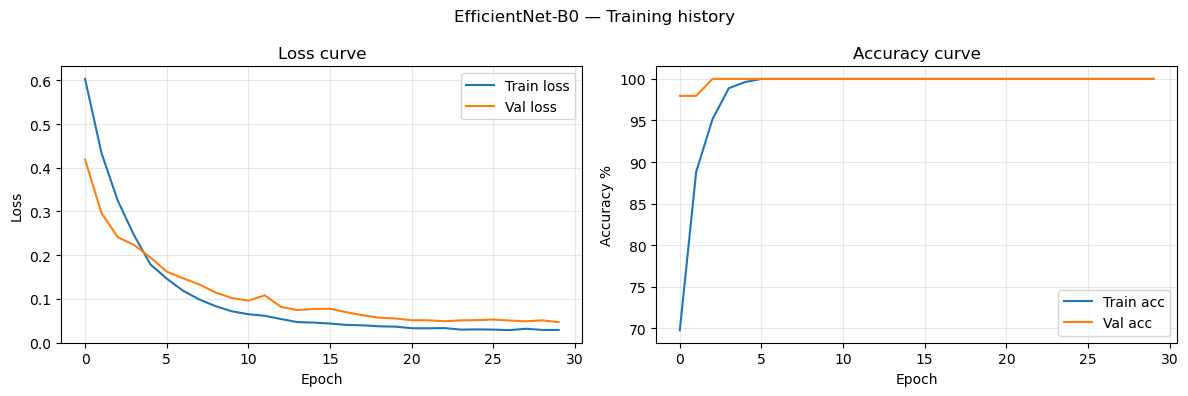

In [31]:
# Cell 16 — Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train loss')
axes[0].plot(history['val_loss'],   label='Val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train acc')
axes[1].plot(history['val_acc'],   label='Val acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy %')
axes[1].set_title('Accuracy curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('EfficientNet-B0 — Training history', fontsize=12)
plt.tight_layout()
plt.show()

/home/joy/miniconda3/envs/ds_study/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  TEST SET EVALUATION
Total test samples : 56
Unique labels      : [1.]
Predictions        : [1.]
Correct            : 56 / 56
Accuracy           : 100.0%
AUC-ROC            : cannot compute — Only one class present in y_true. ROC AUC score is not defined in that case.

NOTE: All test images have label=1 (endo present).
      Binary metrics require negative examples.
      Next step: add GLENDA v1.0 background frames as negatives.


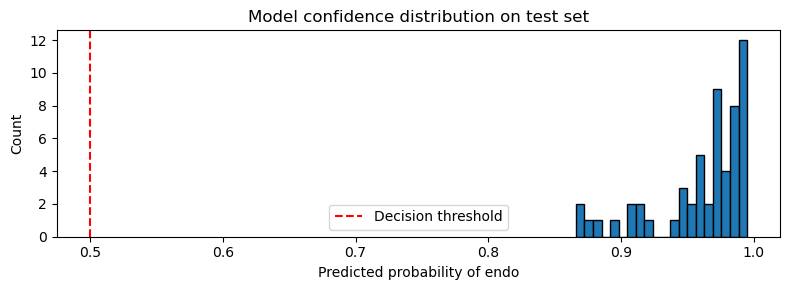


Model saved → ./outputs/efficientnet_b0_endoscan_v1.pt


In [33]:
# Cell 17 — Evaluate on test set + save model
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, ConfusionMatrixDisplay)

model.eval()
all_preds  = []
all_probs  = []
all_labels = []

with torch.no_grad():
    for images_batch, labels_batch in test_loader:
        images_batch = images_batch.to(device)
        outputs      = model(images_batch)
        probs        = torch.sigmoid(outputs).cpu().squeeze(1)
        preds        = (probs > 0.5).float()

        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())
        all_labels.extend(labels_batch.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print('=' * 50)
print('  TEST SET EVALUATION')
print('=' * 50)
print(f'Total test samples : {len(all_labels)}')
print(f'Unique labels      : {np.unique(all_labels)}')
print(f'Predictions        : {np.unique(all_preds)}')
print(f'Correct            : {(all_preds == all_labels).sum()} / {len(all_labels)}')
print(f'Accuracy           : {(all_preds == all_labels).mean()*100:.1f}%')

# AUC still works with one class — but will warn, so we guard it
try:
    auc = roc_auc_score(all_labels, all_probs)
    print(f'AUC-ROC            : {auc:.4f}')
except ValueError as e:
    print(f'AUC-ROC            : cannot compute — {e}')

print()
print('NOTE: All test images have label=1 (endo present).')
print('      Binary metrics require negative examples.')
print('      Next step: add GLENDA v1.0 background frames as negatives.')

# Probability distribution — tells us model confidence
plt.figure(figsize=(8, 3))
plt.hist(all_probs, bins=20, edgecolor='black')
plt.xlabel('Predicted probability of endo')
plt.ylabel('Count')
plt.title('Model confidence distribution on test set')
plt.axvline(0.5, color='red', linestyle='--', label='Decision threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Save model
import os
os.makedirs('./outputs', exist_ok=True)
torch.save({
    'model_state_dict' : model.state_dict(),
    'train_cases'      : list(train_cases),
    'val_cases'        : list(val_cases),
    'test_cases'       : list(test_cases),
    'history'          : history,
    'img_size'         : IMG_SIZE,
}, './outputs/efficientnet_b0_endoscan_v1.pt')

print('\nModel saved → ./outputs/efficientnet_b0_endoscan_v1.pt')

In [34]:
# Cell 18 — Download GLENDA v1.0 negatives
# ~1.7GB, will take a few minutes depending on your connection

import urllib.request
import zipfile
import os

GLENDA_URL  = 'ftp://ftp.itec.aau.at/datasets/GLENDA/v1_0/GLENDA_v1_0.zip'
GLENDA_ZIP  = './GLENDA_v1_0.zip'
GLENDA_DIR  = './GLENDA_v1_0'

# Download
print('Downloading GLENDA v1.0 (~1.7GB)...')
print('This will take a few minutes — go get some chai ☕')

def download_progress(block_num, block_size, total_size):
    downloaded = block_num * block_size
    pct = min(downloaded / total_size * 100, 100)
    print(f'\r  {pct:.1f}% — {downloaded/1e6:.0f}MB / {total_size/1e6:.0f}MB',
          end='', flush=True)

urllib.request.urlretrieve(GLENDA_URL, GLENDA_ZIP, reporthook=download_progress)
print('\nDownload complete.')

This will take a few minutes — go get some chai ☕


URLError: <urlopen error <urlopen error ftp error: error_perm('550 GLENDA_v1_0.zip: No such file or directory')>>

In [35]:
# Cell 18b — Browse the FTP to find the right filename
import ftplib

ftp = ftplib.FTP('ftp.itec.aau.at')
ftp.login()  # anonymous login

# Navigate to GLENDA folder
ftp.cwd('/datasets/GLENDA')
print('Contents of /datasets/GLENDA/:')
ftp.dir()

print()

# Check v1_0 subfolder
try:
    ftp.cwd('v1_0')
    print('\nContents of /datasets/GLENDA/v1_0/:')
    ftp.dir()
except:
    print('No v1_0 subfolder found')

ftp.quit()

Contents of /datasets/GLENDA/:
drwxrwxr-x   2 ftp      nogroup         4 Mar 17  2021 downloads
-rw-rw-r--   1 ftp      nogroup     15559 May  5  2022 index.html
drwxrwxr-x   3 ftp      nogroup         3 Mar 17  2021 lib
-rw-rw-r--   1 ftp      nogroup      2524 May  5  2022 style.css
drwxrwxr-x   4 ftp      nogroup         6 Mar 31  2022 v1_0
drwxrwxr-x   3 ftp      nogroup         3 Mar 17  2021 visualizations


Contents of /datasets/GLENDA/v1_0/:
drwxrwxr-x   2 ftp      nogroup         4 Mar 31  2022 downloads
drwxrwxr-x   7 ftp      nogroup         7 Sep 30  2019 images
-rw-rw-r--   1 ftp      nogroup     24638 May  5  2022 index.html
-rw-rw-r--   1 ftp      nogroup      1675 May  5  2022 style.css


'221 Goodbye.'

In [36]:
# Cell 18c — Check downloads folder
ftp = ftplib.FTP('ftp.itec.aau.at')
ftp.login()
ftp.cwd('/datasets/GLENDA/v1_0/downloads')
print('Contents of /datasets/GLENDA/v1_0/downloads/:')
ftp.dir()

print()

# Also check images folder structure
ftp.cwd('../images')
print('Contents of /datasets/GLENDA/v1_0/images/:')
ftp.dir()

ftp.quit()

Contents of /datasets/GLENDA/v1_0/downloads/:
-rw-rw-r--   1 ftp      nogroup  1737585763 Sep 30  2019 GLENDA_v1.0.zip
-rw-rw-r--   1 ftp      nogroup  21866743 May  8  2020 GLENDA_v1.0_no_segments_multicolor.zip

Contents of /datasets/GLENDA/v1_0/images/:
drwxrwxr-x   3 ftp      nogroup        13 Sep 30  2019 die
drwxrwxr-x   3 ftp      nogroup        18 Sep 30  2019 no_pathology
drwxrwxr-x   3 ftp      nogroup        13 Sep 30  2019 ovary
drwxrwxr-x   3 ftp      nogroup        13 Sep 30  2019 peritoneum
drwxrwxr-x   3 ftp      nogroup        13 Sep 30  2019 uterus


'221 Goodbye.'

In [37]:
# Cell 18d — Check no_pathology folder structure
ftp = ftplib.FTP('ftp.itec.aau.at')
ftp.login()

ftp.cwd('/datasets/GLENDA/v1_0/images/no_pathology')
print('Contents of no_pathology/:')
ftp.dir()

# Go one level deeper
subdirs = ftp.nlst()
print(f'\nSubfolders: {subdirs}')

for subdir in subdirs[:3]:  # check first 3
    try:
        ftp.cwd(f'/datasets/GLENDA/v1_0/images/no_pathology/{subdir}')
        files = ftp.nlst()
        print(f'\n  {subdir}/  → {len(files)} files')
        print(f'  Sample: {files[:3]}')
    except:
        pass

ftp.quit()

Contents of no_pathology/:
-rw-rw-r--   1 ftp      nogroup      7848 May  5  2022 0.jpg
-rw-rw-r--   1 ftp      nogroup      9139 May  5  2022 1.jpg
-rw-rw-r--   1 ftp      nogroup      8751 May  5  2022 10.jpg
-rw-rw-r--   1 ftp      nogroup      8458 May  5  2022 11.jpg
-rw-rw-r--   1 ftp      nogroup      8219 May  5  2022 12.jpg
-rw-rw-r--   1 ftp      nogroup      7923 May  5  2022 13.jpg
-rw-rw-r--   1 ftp      nogroup      8758 May  5  2022 14.jpg
-rw-rw-r--   1 ftp      nogroup      9374 May  5  2022 2.jpg
-rw-rw-r--   1 ftp      nogroup      8892 May  5  2022 3.jpg
-rw-rw-r--   1 ftp      nogroup      8004 May  5  2022 4.jpg
-rw-rw-r--   1 ftp      nogroup      8316 May  5  2022 5.jpg
-rw-rw-r--   1 ftp      nogroup      8972 May  5  2022 6.jpg
-rw-rw-r--   1 ftp      nogroup      6629 May  5  2022 7.jpg
-rw-rw-r--   1 ftp      nogroup      8005 May  5  2022 8.jpg
-rw-rw-r--   1 ftp      nogroup      8078 May  5  2022 9.jpg
drwxrwxr-x   2 ftp      nogroup         7 Sep 30  201

'221 Goodbye.'

In [38]:
# Cell 18e — Check seq subfolder for more negatives
ftp = ftplib.FTP('ftp.itec.aau.at')
ftp.login()

ftp.cwd('/datasets/GLENDA/v1_0/images/no_pathology/seq')
print('Contents of no_pathology/seq/:')
ftp.dir()

# Check subdirs
subdirs = [f for f in ftp.nlst() if not f.endswith('.jpg')]
print(f'\nSubfolders found: {len(subdirs)}')
print(f'First 5: {subdirs[:5]}')

# Count total images across all seq subfolders
total = 0
for subdir in subdirs:
    try:
        ftp.cwd(f'/datasets/GLENDA/v1_0/images/no_pathology/seq/{subdir}')
        files = [f for f in ftp.nlst() if f.endswith('.jpg')]
        total += len(files)
    except:
        pass

print(f'\nTotal images in seq/: {total}')
ftp.quit()

Contents of no_pathology/seq/:
-rw-rw-r--   1 ftp      nogroup      8393 May  5  2022 0.jpg
-rw-rw-r--   1 ftp      nogroup      7679 May  5  2022 1.jpg
-rw-rw-r--   1 ftp      nogroup      7544 May  5  2022 2.jpg
-rw-rw-r--   1 ftp      nogroup      8283 May  5  2022 3.jpg
-rw-rw-r--   1 ftp      nogroup      8330 May  5  2022 4.jpg

Subfolders found: 0
First 5: []

Total images in seq/: 0


'221 Goodbye.'

In [39]:
# Cell 18f — Count images across ALL v1.0 folders
ftp = ftplib.FTP('ftp.itec.aau.at')
ftp.login()

base = '/datasets/GLENDA/v1_0/images'
folders = ['no_pathology', 'peritoneum', 'ovary', 'uterus', 'die']

for folder in folders:
    try:
        ftp.cwd(f'{base}/{folder}')
        all_files = ftp.nlst()
        jpgs = [f for f in all_files if f.endswith('.jpg')]
        subdirs = [f for f in all_files if not f.endswith('.jpg')]
        
        # Count in subdirs too
        subdir_count = 0
        for sub in subdirs:
            try:
                ftp.cwd(f'{base}/{folder}/{sub}')
                subdir_count += len([f for f in ftp.nlst() if f.endswith('.jpg')])
            except:
                pass
        
        print(f'{folder:20s}: {len(jpgs):5d} direct + {subdir_count:5d} in subdirs = {len(jpgs)+subdir_count:5d} total')
    except Exception as e:
        print(f'{folder:20s}: error — {e}')

ftp.quit()

no_pathology        :    15 direct +     5 in subdirs =    20 total
peritoneum          :     5 direct +     4 in subdirs =     9 total
ovary               :     5 direct +     4 in subdirs =     9 total
uterus              :     5 direct +     4 in subdirs =     9 total
die                 :     5 direct +     4 in subdirs =     9 total


'221 Goodbye.'

In [40]:
# Cell 18g — Check HuggingFace cache for usable negatives
import os
from pathlib import Path

cache_path = Path('/home/joy/.cache/huggingface/hub/datasets--MFreidank--glenda/snapshots/e9195188dbd6939e10785e3ed9ee1c513731c9bc')

print('Cache contents:')
for item in sorted(cache_path.iterdir()):
    if item.is_dir():
        files = list(item.rglob('*.jpg')) + list(item.rglob('*.png'))
        print(f'  DIR  {item.name}/  → {len(files)} images')
    else:
        print(f'  FILE {item.name}  ({item.stat().st_size/1e6:.1f}MB)')

Cache contents:
  FILE .gitattributes  (0.0MB)
  FILE LICENSE.txt  (0.0MB)
  FILE README.md  (0.0MB)
  FILE glenda.py  (0.0MB)


Generating synthetic negatives from training images...
Generated 223 negative crops
Saved to  Glenda_v1.5_classes/synthetic_negatives


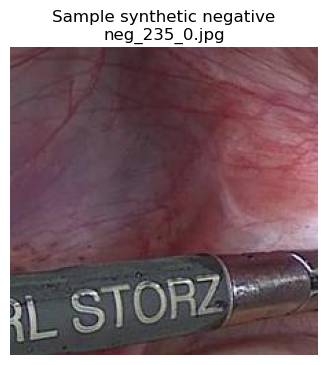

In [41]:
# Cell 19 — Synthetic negatives from background regions
# Strategy: for each annotated image, extract a crop from a region
# confirmed to have NO lesion pixels (mask == 0 everywhere in crop).
# These are real laparoscopy tissue frames, just lesion-free regions.

from PIL import Image
import numpy as np
from pathlib import Path
import os

NEGATIVES_DIR = Path('./Glenda_v1.5_classes/synthetic_negatives')
NEGATIVES_DIR.mkdir(exist_ok=True)

CROP_SIZE   = 224   # same as model input
MIN_COVERAGE = 0.0  # crop must have 0% lesion pixels

def extract_negative_crops(img_meta, n_crops=2):
    """
    Try to extract n_crops background-only patches from an image.
    Returns list of PIL images where mask is entirely black.
    """
    img_id   = img_meta['id']
    meta     = img_id_to_meta[img_id]
    img_path = IMAGES_DIR / Path(meta['file_name']).name
    
    raw_img  = np.array(Image.open(img_path).convert('RGB'))
    mask     = create_binary_mask(img_id, meta['width'], meta['height'])
    
    h, w    = raw_img.shape[:2]
    crops   = []
    attempts = 0
    
    while len(crops) < n_crops and attempts < 50:
        # Random top-left corner
        x = np.random.randint(0, max(1, w - CROP_SIZE))
        y = np.random.randint(0, max(1, h - CROP_SIZE))
        
        # Check mask in this region
        mask_crop = mask[y:y+CROP_SIZE, x:x+CROP_SIZE]
        
        # Only keep if NO lesion pixels in crop
        if mask_crop.max() == 0 and mask_crop.shape == (CROP_SIZE, CROP_SIZE):
            img_crop = raw_img[y:y+CROP_SIZE, x:x+CROP_SIZE]
            crops.append(Image.fromarray(img_crop))
        
        attempts += 1
    
    return crops


# Generate negatives from all training images
print('Generating synthetic negatives from training images...')
neg_count = 0

for img_meta in train_imgs:
    crops = extract_negative_crops(img_meta, n_crops=1)
    for i, crop in enumerate(crops):
        fname = f"neg_{img_meta['id']}_{i}.jpg"
        crop.save(NEGATIVES_DIR / fname)
        neg_count += 1

print(f'Generated {neg_count} negative crops')
print(f'Saved to  {NEGATIVES_DIR}')

# Verify one looks right
sample_neg = list(NEGATIVES_DIR.glob('*.jpg'))[:1][0]
img        = Image.open(sample_neg)

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f'Sample synthetic negative\n{sample_neg.name}')
plt.axis('off')
plt.show()

In [42]:
# Cell 20 — Rebuild dataset with positives + negatives

class GLENDABinaryDataset(Dataset):
    """
    Balanced binary dataset.
    Positive (label=1): original GLENDA v1.5 annotated frames
    Negative (label=0): synthetic background crops
    """

    def __init__(self, pos_img_list, neg_paths, img_id_to_meta,
                 images_dir, transform=None):
        self.samples   = []
        self.transform = transform
        images_dir     = Path(images_dir)

        # Positives
        for img_meta in pos_img_list:
            meta     = img_id_to_meta[img_meta['id']]
            img_path = images_dir / Path(meta['file_name']).name
            self.samples.append((img_path, 1.0))

        # Negatives
        for neg_path in neg_paths:
            self.samples.append((Path(neg_path), 0.0))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = np.array(Image.open(img_path).convert('RGB'))

        if self.transform:
            result = self.transform(image=image)
            image  = result['image']

        return image, torch.tensor(label, dtype=torch.float32)


# Split negatives across train/val/test (same 70/15/15 ratio)
all_neg_paths = sorted(NEGATIVES_DIR.glob('*.jpg'))
np.random.seed(42)
np.random.shuffle(all_neg_paths)

n_neg       = len(all_neg_paths)
n_neg_train = int(n_neg * 0.70)
n_neg_val   = int(n_neg * 0.15)

neg_train = all_neg_paths[:n_neg_train]
neg_val   = all_neg_paths[n_neg_train:n_neg_train + n_neg_val]
neg_test  = all_neg_paths[n_neg_train + n_neg_val:]

# Rebuild datasets
train_dataset = GLENDABinaryDataset(train_imgs, neg_train, img_id_to_meta,
                                    IMAGES_DIR, transform=train_transform)
val_dataset   = GLENDABinaryDataset(val_imgs,   neg_val,   img_id_to_meta,
                                    IMAGES_DIR, transform=val_transform)
test_dataset  = GLENDABinaryDataset(test_imgs,  neg_test,  img_id_to_meta,
                                    IMAGES_DIR, transform=val_transform)

# Rebuild loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train: {len(train_dataset)} samples '
      f'({len(train_imgs)} pos + {len(neg_train)} neg)')
print(f'Val  : {len(val_dataset)} samples '
      f'({len(val_imgs)} pos + {len(neg_val)} neg)')
print(f'Test : {len(test_dataset)} samples '
      f'({len(test_imgs)} pos + {len(neg_test)} neg)')

# Verify label balance
train_labels = [s[1] for s in train_dataset.samples]
print(f'\nTrain positives: {sum(l==1.0 for l in train_labels)}')
print(f'Train negatives: {sum(l==0.0 for l in train_labels)}')


Train: 424 samples (268 pos + 156 neg)
Val  : 82 samples (49 pos + 33 neg)
Test : 90 samples (56 pos + 34 neg)

Train positives: 268
Train negatives: 156


In [43]:
# Cell 21 — Retrain on balanced dataset
import copy

# Reset model to pretrained weights — start fresh with balanced data
model = timm.create_model('efficientnet_b0', pretrained=True)

for param in model.parameters():
    param.requires_grad = False

for param in model.blocks[6].parameters():
    param.requires_grad = True
for param in model.conv_head.parameters():
    param.requires_grad = True
for param in model.bn2.parameters():
    param.requires_grad = True

in_features      = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 1)
)
model = model.to(device)

# ── Hyperparameters ───────────────────────────────────────────────
EPOCHS = 40
LR     = 1e-4

# Weighted loss — positives slightly upweighted since sensitivity matters more
# Missing a real case (false negative) is worse than a false alarm
pos_weight = torch.tensor([268 / 156]).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
# ─────────────────────────────────────────────────────────────────

best_val_loss = float('inf')
best_weights  = None
history       = {'train_loss': [], 'val_loss': [],
                 'train_acc':  [], 'val_acc':  []}

for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images_batch, labels_batch in train_loader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images_batch)
        loss    = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * images_batch.size(0)
        preds          = (torch.sigmoid(outputs) > 0.5).float()
        train_correct += (preds == labels_batch).sum().item()
        train_total   += images_batch.size(0)

    scheduler.step()

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images_batch, labels_batch in val_loader:
            images_batch = images_batch.to(device)
            labels_batch = labels_batch.to(device).unsqueeze(1)

            outputs   = model(images_batch)
            loss      = criterion(outputs, labels_batch)

            val_loss    += loss.item() * images_batch.size(0)
            preds        = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds == labels_batch).sum().item()
            val_total   += images_batch.size(0)

    train_loss_avg = train_loss / train_total
    val_loss_avg   = val_loss   / val_total
    train_acc      = train_correct / train_total * 100
    val_acc        = val_correct   / val_total   * 100

    history['train_loss'].append(train_loss_avg)
    history['val_loss'].append(val_loss_avg)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_loss_avg < best_val_loss:
        best_val_loss = val_loss_avg
        best_weights  = copy.deepcopy(model.state_dict())
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
              f'Train loss: {train_loss_avg:.4f} acc: {train_acc:.1f}% | '
              f'Val loss: {val_loss_avg:.4f} acc: {val_acc:.1f}%  ← best')
    else:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
              f'Train loss: {train_loss_avg:.4f} acc: {train_acc:.1f}% | '
              f'Val loss: {val_loss_avg:.4f} acc: {val_acc:.1f}%')

model.load_state_dict(best_weights)
print(f'\nTraining complete. Best val loss: {best_val_loss:.4f}')

/home/joy/miniconda3/envs/ds_study/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/40 | Train loss: 0.8309 acc: 62.5% | Val loss: 0.6568 acc: 67.1%  ← best
Epoch   2/40 | Train loss: 0.6790 acc: 75.2% | Val loss: 0.5136 acc: 76.8%  ← best
Epoch   3/40 | Train loss: 0.5395 acc: 80.9% | Val loss: 0.3999 acc: 84.1%  ← best
Epoch   4/40 | Train loss: 0.4738 acc: 84.4% | Val loss: 0.3159 acc: 87.8%  ← best
Epoch   5/40 | Train loss: 0.4276 acc: 85.8% | Val loss: 0.2814 acc: 92.7%  ← best
Epoch   6/40 | Train loss: 0.3691 acc: 87.7% | Val loss: 0.2607 acc: 93.9%  ← best
Epoch   7/40 | Train loss: 0.3743 acc: 87.5% | Val loss: 0.2117 acc: 95.1%  ← best
Epoch   8/40 | Train loss: 0.3635 acc: 87.7% | Val loss: 0.1880 acc: 97.6%  ← best
Epoch   9/40 | Train loss: 0.3370 acc: 89.9% | Val loss: 0.1754 acc: 97.6%  ← best
Epoch  10/40 | Train loss: 0.3517 acc: 87.0% | Val loss: 0.1813 acc: 95.1%
Epoch  11/40 | Train loss: 0.3566 acc: 86.1% | Val loss: 0.1711 acc: 97.6%  ← best
Epoch  12/40 | Train loss: 0.3257 acc: 88.4% | Val loss: 0.1547 acc: 98.8%  ← best
Epoch  13/40

  PHASE 5 — EVALUATION

Test samples : 90 (56 pos / 34 neg)

                  precision    recall  f1-score   support

     No endo (0)      1.000     0.971     0.985        34
Endo present (1)      0.982     1.000     0.991        56

        accuracy                          0.989        90
       macro avg      0.991     0.985     0.988        90
    weighted avg      0.989     0.989     0.989        90

AUC-ROC : 1.0000


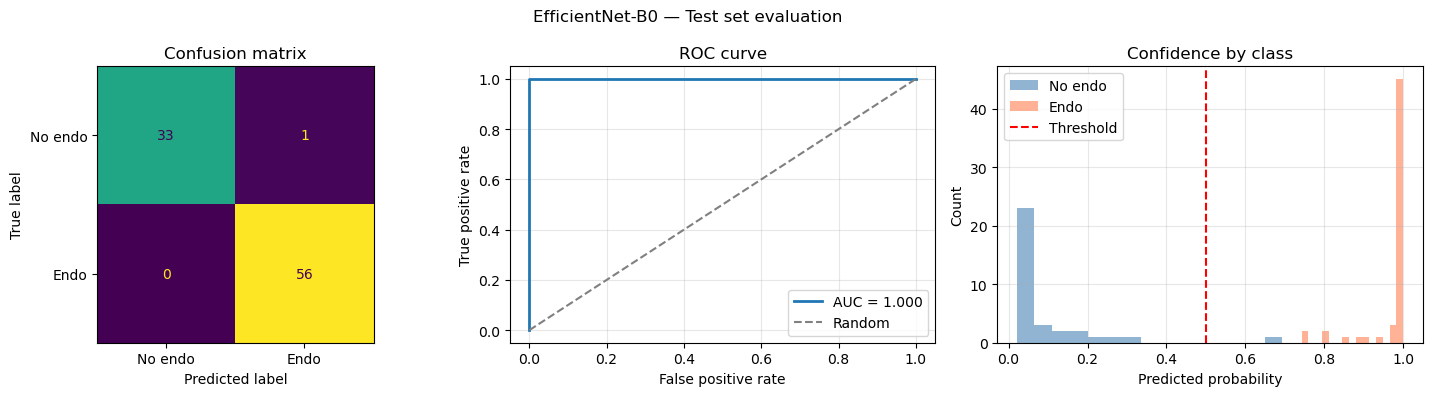


Model saved → ./outputs/efficientnet_b0_endoscan_v1.pt


In [44]:
# Cell 22 — Full evaluation on test set
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              ConfusionMatrixDisplay)

model.eval()
all_preds  = []
all_probs  = []
all_labels = []

with torch.no_grad():
    for images_batch, labels_batch in test_loader:
        images_batch = images_batch.to(device)
        outputs      = model(images_batch)
        probs        = torch.sigmoid(outputs).cpu().squeeze(1)
        preds        = (probs > 0.5).float()

        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())
        all_labels.extend(labels_batch.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print('=' * 55)
print('  PHASE 5 — EVALUATION')
print('=' * 55)
print(f'\nTest samples : {len(all_labels)} '
      f'({int(all_labels.sum())} pos / {int((all_labels==0).sum())} neg)')
print()
print(classification_report(
    all_labels, all_preds,
    target_names=['No endo (0)', 'Endo present (1)'],
    digits=3
))

auc = roc_auc_score(all_labels, all_probs)
print(f'AUC-ROC : {auc:.4f}')
print('=' * 55)

# ── Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=['No endo', 'Endo']).plot(
    ax=axes[0], colorbar=False)
axes[0].set_title('Confusion matrix')

# 2. ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1],'--', color='gray', label='Random')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].set_title('ROC curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Confidence distribution by class
pos_probs = all_probs[all_labels == 1]
neg_probs = all_probs[all_labels == 0]
axes[2].hist(neg_probs, bins=15, alpha=0.6, label='No endo', color='steelblue')
axes[2].hist(pos_probs, bins=15, alpha=0.6, label='Endo',    color='coral')
axes[2].axvline(0.5, color='red', linestyle='--', label='Threshold')
axes[2].set_xlabel('Predicted probability')
axes[2].set_ylabel('Count')
axes[2].set_title('Confidence by class')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('EfficientNet-B0 — Test set evaluation', fontsize=12)
plt.tight_layout()
plt.show()

# Save final model
os.makedirs('./outputs', exist_ok=True)
torch.save({
    'model_state_dict' : model.state_dict(),
    'train_cases'      : list(train_cases),
    'val_cases'        : list(val_cases),
    'test_cases'       : list(test_cases),
    'history'          : history,
    'img_size'         : IMG_SIZE,
    'auc'              : auc,
}, './outputs/efficientnet_b0_endoscan_v1.pt')

print(f'\nModel saved → ./outputs/efficientnet_b0_endoscan_v1.pt')

In [45]:
# Cell 23 — Find GLENDA v1.0 real negatives
import os
from pathlib import Path

# Find where it extracted
glenda_root = Path.home() / 'Downloads' / 'GLENDA_v1_0'

print('Searching for no_pathology folder...')
for path in glenda_root.rglob('no_pathology'):
    if path.is_dir():
        images = list(path.rglob('*.jpg')) + list(path.rglob('*.png'))
        print(f'Found: {path}')
        print(f'Images: {len(images)}')
        print(f'Sample: {[img.name for img in images[:5]]}')

Searching for no_pathology folder...
Found: /home/joy/Downloads/GLENDA_v1_0/GLENDA_v1.0/DS/no_pathology
Images: 13438
Sample: ['f_338.jpg', 'f_427.jpg', 'f_447.jpg', 'f_438.jpg', 'f_231.jpg']


Total real negatives available: 13438

Train:  529 samples (268 pos / 261 neg)
Val  :  104 samples (49 pos / 55 neg)
Test :  113 samples (56 pos / 57 neg)


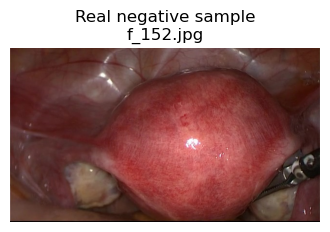

In [46]:
# Cell 24 — Rebuild dataset with real GLENDA v1.0 negatives

REAL_NEG_DIR = Path.home() / 'Downloads/GLENDA_v1_0/GLENDA_v1.0/DS/no_pathology'

# Load all real negative paths and sample to ~373 to keep balance
all_real_negs = list(REAL_NEG_DIR.rglob('*.jpg'))
print(f'Total real negatives available: {len(all_real_negs)}')

# Shuffle and sample — we want roughly same number as positives
np.random.seed(42)
np.random.shuffle(all_real_negs)
sampled_negs = all_real_negs[:373]   # match positive count

# Split negatives 70/15/15
n_neg       = len(sampled_negs)
n_neg_train = int(n_neg * 0.70)
n_neg_val   = int(n_neg * 0.15)

neg_train = sampled_negs[:n_neg_train]
neg_val   = sampled_negs[n_neg_train:n_neg_train + n_neg_val]
neg_test  = sampled_negs[n_neg_train + n_neg_val:]

# Rebuild datasets
train_dataset = GLENDABinaryDataset(train_imgs, neg_train, img_id_to_meta,
                                    IMAGES_DIR, transform=train_transform)
val_dataset   = GLENDABinaryDataset(val_imgs,   neg_val,   img_id_to_meta,
                                    IMAGES_DIR, transform=val_transform)
test_dataset  = GLENDABinaryDataset(test_imgs,  neg_test,  img_id_to_meta,
                                    IMAGES_DIR, transform=val_transform)

# Rebuild loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=True)

# Verify
train_labels = [s[1] for s in train_dataset.samples]
val_labels   = [s[1] for s in val_dataset.samples]
test_labels  = [s[1] for s in test_dataset.samples]

print(f'\nTrain: {len(train_dataset):4d} samples '
      f'({int(sum(l==1 for l in train_labels))} pos / '
      f'{int(sum(l==0 for l in train_labels))} neg)')
print(f'Val  : {len(val_dataset):4d} samples '
      f'({int(sum(l==1 for l in val_labels))} pos / '
      f'{int(sum(l==0 for l in val_labels))} neg)')
print(f'Test : {len(test_dataset):4d} samples '
      f'({int(sum(l==1 for l in test_labels))} pos / '
      f'{int(sum(l==0 for l in test_labels))} neg)')

# Sanity check — peek at one real negative
sample_neg = Image.open(neg_train[0]).convert('RGB')
plt.figure(figsize=(4, 4))
plt.imshow(sample_neg)
plt.title(f'Real negative sample\n{neg_train[0].name}')
plt.axis('off')
plt.show()

In [47]:
# Cell 25 — Final training run with real negatives

# Reset model fresh
model = timm.create_model('efficientnet_b0', pretrained=True)

for param in model.parameters():
    param.requires_grad = False

for param in model.blocks[6].parameters():
    param.requires_grad = True
for param in model.conv_head.parameters():
    param.requires_grad = True
for param in model.bn2.parameters():
    param.requires_grad = True

in_features      = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 1)
)
model = model.to(device)

# Balanced classes — no pos_weight needed this time
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-6)

EPOCHS        = 40
best_val_loss = float('inf')
best_weights  = None
history       = {'train_loss': [], 'val_loss': [],
                 'train_acc':  [], 'val_acc':  []}

for epoch in range(EPOCHS):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images_batch, labels_batch in train_loader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images_batch)
        loss    = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * images_batch.size(0)
        preds          = (torch.sigmoid(outputs) > 0.5).float()
        train_correct += (preds == labels_batch).sum().item()
        train_total   += images_batch.size(0)

    scheduler.step()

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images_batch, labels_batch in val_loader:
            images_batch = images_batch.to(device)
            labels_batch = labels_batch.to(device).unsqueeze(1)
            outputs      = model(images_batch)
            loss         = criterion(outputs, labels_batch)

            val_loss    += loss.item() * images_batch.size(0)
            preds        = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds == labels_batch).sum().item()
            val_total   += images_batch.size(0)

    train_loss_avg = train_loss / train_total
    val_loss_avg   = val_loss   / val_total
    train_acc      = train_correct / train_total * 100
    val_acc        = val_correct   / val_total   * 100

    history['train_loss'].append(train_loss_avg)
    history['val_loss'].append(val_loss_avg)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_loss_avg < best_val_loss:
        best_val_loss = val_loss_avg
        best_weights  = copy.deepcopy(model.state_dict())
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
              f'Train loss: {train_loss_avg:.4f} acc: {train_acc:.1f}% | '
              f'Val loss: {val_loss_avg:.4f} acc: {val_acc:.1f}%  ← best')
    else:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
              f'Train loss: {train_loss_avg:.4f} acc: {train_acc:.1f}% | '
              f'Val loss: {val_loss_avg:.4f} acc: {val_acc:.1f}%')

model.load_state_dict(best_weights)
print(f'\nFinal training complete. Best val loss: {best_val_loss:.4f}')

/home/joy/miniconda3/envs/ds_study/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/40 | Train loss: 0.6794 acc: 55.4% | Val loss: 0.5977 acc: 79.8%  ← best
Epoch   2/40 | Train loss: 0.6171 acc: 66.4% | Val loss: 0.5357 acc: 76.0%  ← best
Epoch   3/40 | Train loss: 0.5583 acc: 72.8% | Val loss: 0.4716 acc: 81.7%  ← best
Epoch   4/40 | Train loss: 0.5282 acc: 74.5% | Val loss: 0.4282 acc: 85.6%  ← best
Epoch   5/40 | Train loss: 0.4880 acc: 76.6% | Val loss: 0.3976 acc: 85.6%  ← best
Epoch   6/40 | Train loss: 0.4521 acc: 79.2% | Val loss: 0.3837 acc: 83.7%  ← best
Epoch   7/40 | Train loss: 0.4440 acc: 77.3% | Val loss: 0.3624 acc: 84.6%  ← best
Epoch   8/40 | Train loss: 0.4181 acc: 80.7% | Val loss: 0.3513 acc: 85.6%  ← best
Epoch   9/40 | Train loss: 0.4239 acc: 79.0% | Val loss: 0.3384 acc: 84.6%  ← best
Epoch  10/40 | Train loss: 0.4326 acc: 77.7% | Val loss: 0.3041 acc: 90.4%  ← best
Epoch  11/40 | Train loss: 0.3898 acc: 82.4% | Val loss: 0.2949 acc: 89.4%  ← best
Epoch  12/40 | Train loss: 0.3936 acc: 79.2% | Val loss: 0.3023 acc: 88.5%
Epoch  13/40

  FINAL EVALUATION — REAL NEGATIVES (GLENDA v1.0)

Test samples : 113 (56 pos / 57 neg)

                  precision    recall  f1-score   support

     No endo (0)      0.900     0.947     0.923        57
Endo present (1)      0.943     0.893     0.917        56

        accuracy                          0.920       113
       macro avg      0.922     0.920     0.920       113
    weighted avg      0.922     0.920     0.920       113

AUC-ROC : 0.9862


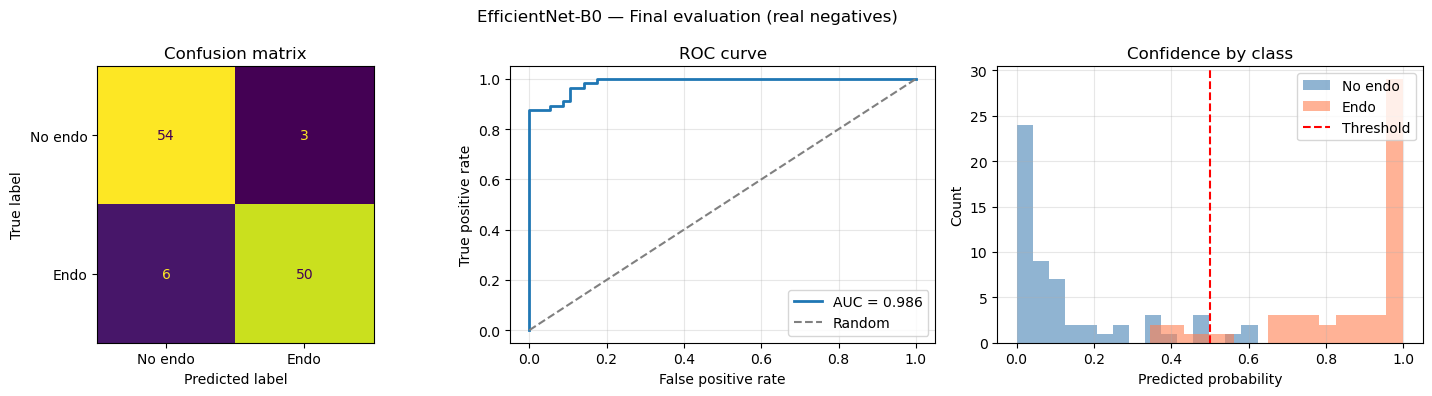

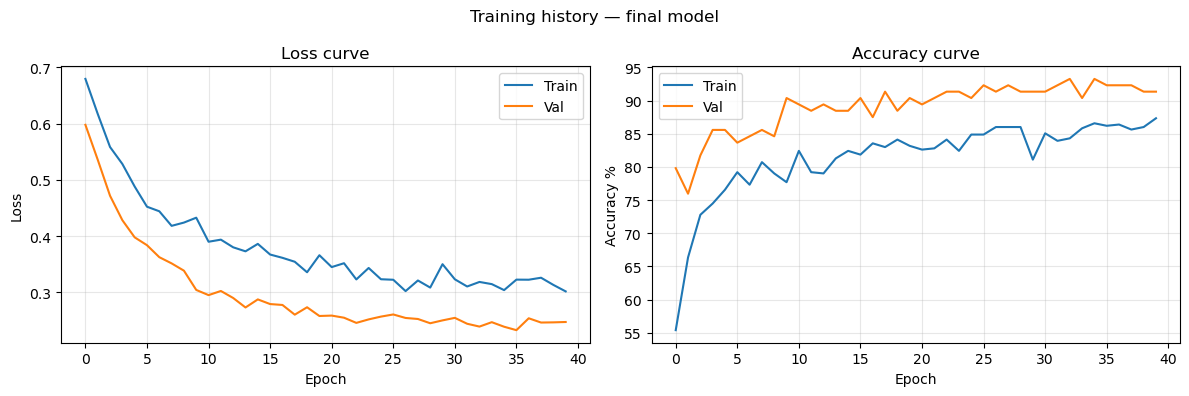


Final model saved → ./outputs/efficientnet_b0_endoscan_final.pt


In [48]:
# Cell 26 — Final honest evaluation on test set
model.eval()
all_preds  = []
all_probs  = []
all_labels = []

with torch.no_grad():
    for images_batch, labels_batch in test_loader:
        images_batch = images_batch.to(device)
        outputs      = model(images_batch)
        probs        = torch.sigmoid(outputs).cpu().squeeze(1)
        preds        = (probs > 0.5).float()

        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())
        all_labels.extend(labels_batch.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print('=' * 55)
print('  FINAL EVALUATION — REAL NEGATIVES (GLENDA v1.0)')
print('=' * 55)
print(f'\nTest samples : {len(all_labels)} '
      f'({int(all_labels.sum())} pos / {int((all_labels==0).sum())} neg)\n')
print(classification_report(
    all_labels, all_preds,
    target_names=['No endo (0)', 'Endo present (1)'],
    digits=3
))
auc = roc_auc_score(all_labels, all_probs)
print(f'AUC-ROC : {auc:.4f}')
print('=' * 55)

# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=['No endo', 'Endo']).plot(
    ax=axes[0], colorbar=False)
axes[0].set_title('Confusion matrix')

fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1],'--', color='gray', label='Random')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].set_title('ROC curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

pos_probs = all_probs[all_labels == 1]
neg_probs = all_probs[all_labels == 0]
axes[2].hist(neg_probs, bins=15, alpha=0.6, label='No endo', color='steelblue')
axes[2].hist(pos_probs, bins=15, alpha=0.6, label='Endo',    color='coral')
axes[2].axvline(0.5, color='red', linestyle='--', label='Threshold')
axes[2].set_xlabel('Predicted probability')
axes[2].set_ylabel('Count')
axes[2].set_title('Confidence by class')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('EfficientNet-B0 — Final evaluation (real negatives)', fontsize=12)
plt.tight_layout()
plt.show()

# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'],   label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy %')
axes[1].set_title('Accuracy curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Training history — final model', fontsize=12)
plt.tight_layout()
plt.show()

# Save
torch.save({
    'model_state_dict' : model.state_dict(),
    'train_cases'      : list(train_cases),
    'val_cases'        : list(val_cases),
    'test_cases'       : list(test_cases),
    'history'          : history,
    'img_size'         : IMG_SIZE,
    'auc'              : auc,
    'negatives'        : 'GLENDA_v1.0_real',
}, './outputs/efficientnet_b0_endoscan_final.pt')

print('\nFinal model saved → ./outputs/efficientnet_b0_endoscan_final.pt')

In [49]:
# Cell 27 — Grad-CAM implementation
# No extra libraries needed — we build it from scratch using hooks

class GradCAM:
    """
    Gradient-weighted Class Activation Mapping.
    Hooks into the last convolutional layer and computes
    a heatmap showing which regions influenced the prediction.
    """

    def __init__(self, model):
        self.model      = model
        self.gradients  = None
        self.activations = None

        # Hook into the last conv block — blocks[6] in EfficientNet-B0
        target_layer = model.blocks[6]

        # Forward hook — saves activations
        target_layer.register_forward_hook(self._save_activations)

        # Backward hook — saves gradients
        target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        """
        Returns:
            prob     : predicted probability of endo (float)
            heatmap  : numpy array (H, W) normalised 0-1
        """
        self.model.eval()
        input_tensor = input_tensor.unsqueeze(0)  # add batch dim
        input_tensor.requires_grad_(True)

        # Forward pass
        output = self.model(input_tensor)
        prob   = torch.sigmoid(output).item()

        # Backward pass on the endo class score
        self.model.zero_grad()
        output.backward()

        # Global average pool the gradients
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # [1, C, 1, 1]

        # Weighted sum of activation maps
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # [1, 1, H, W]
        cam = torch.relu(cam)  # only positive influence
        cam = cam.squeeze().numpy()

        # Normalise to 0-1
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        return prob, cam


# Instantiate GradCAM
gradcam = GradCAM(model)
print('GradCAM ready')
print(f'Hooking into: model.blocks[6]')

GradCAM ready
Hooking into: model.blocks[6]


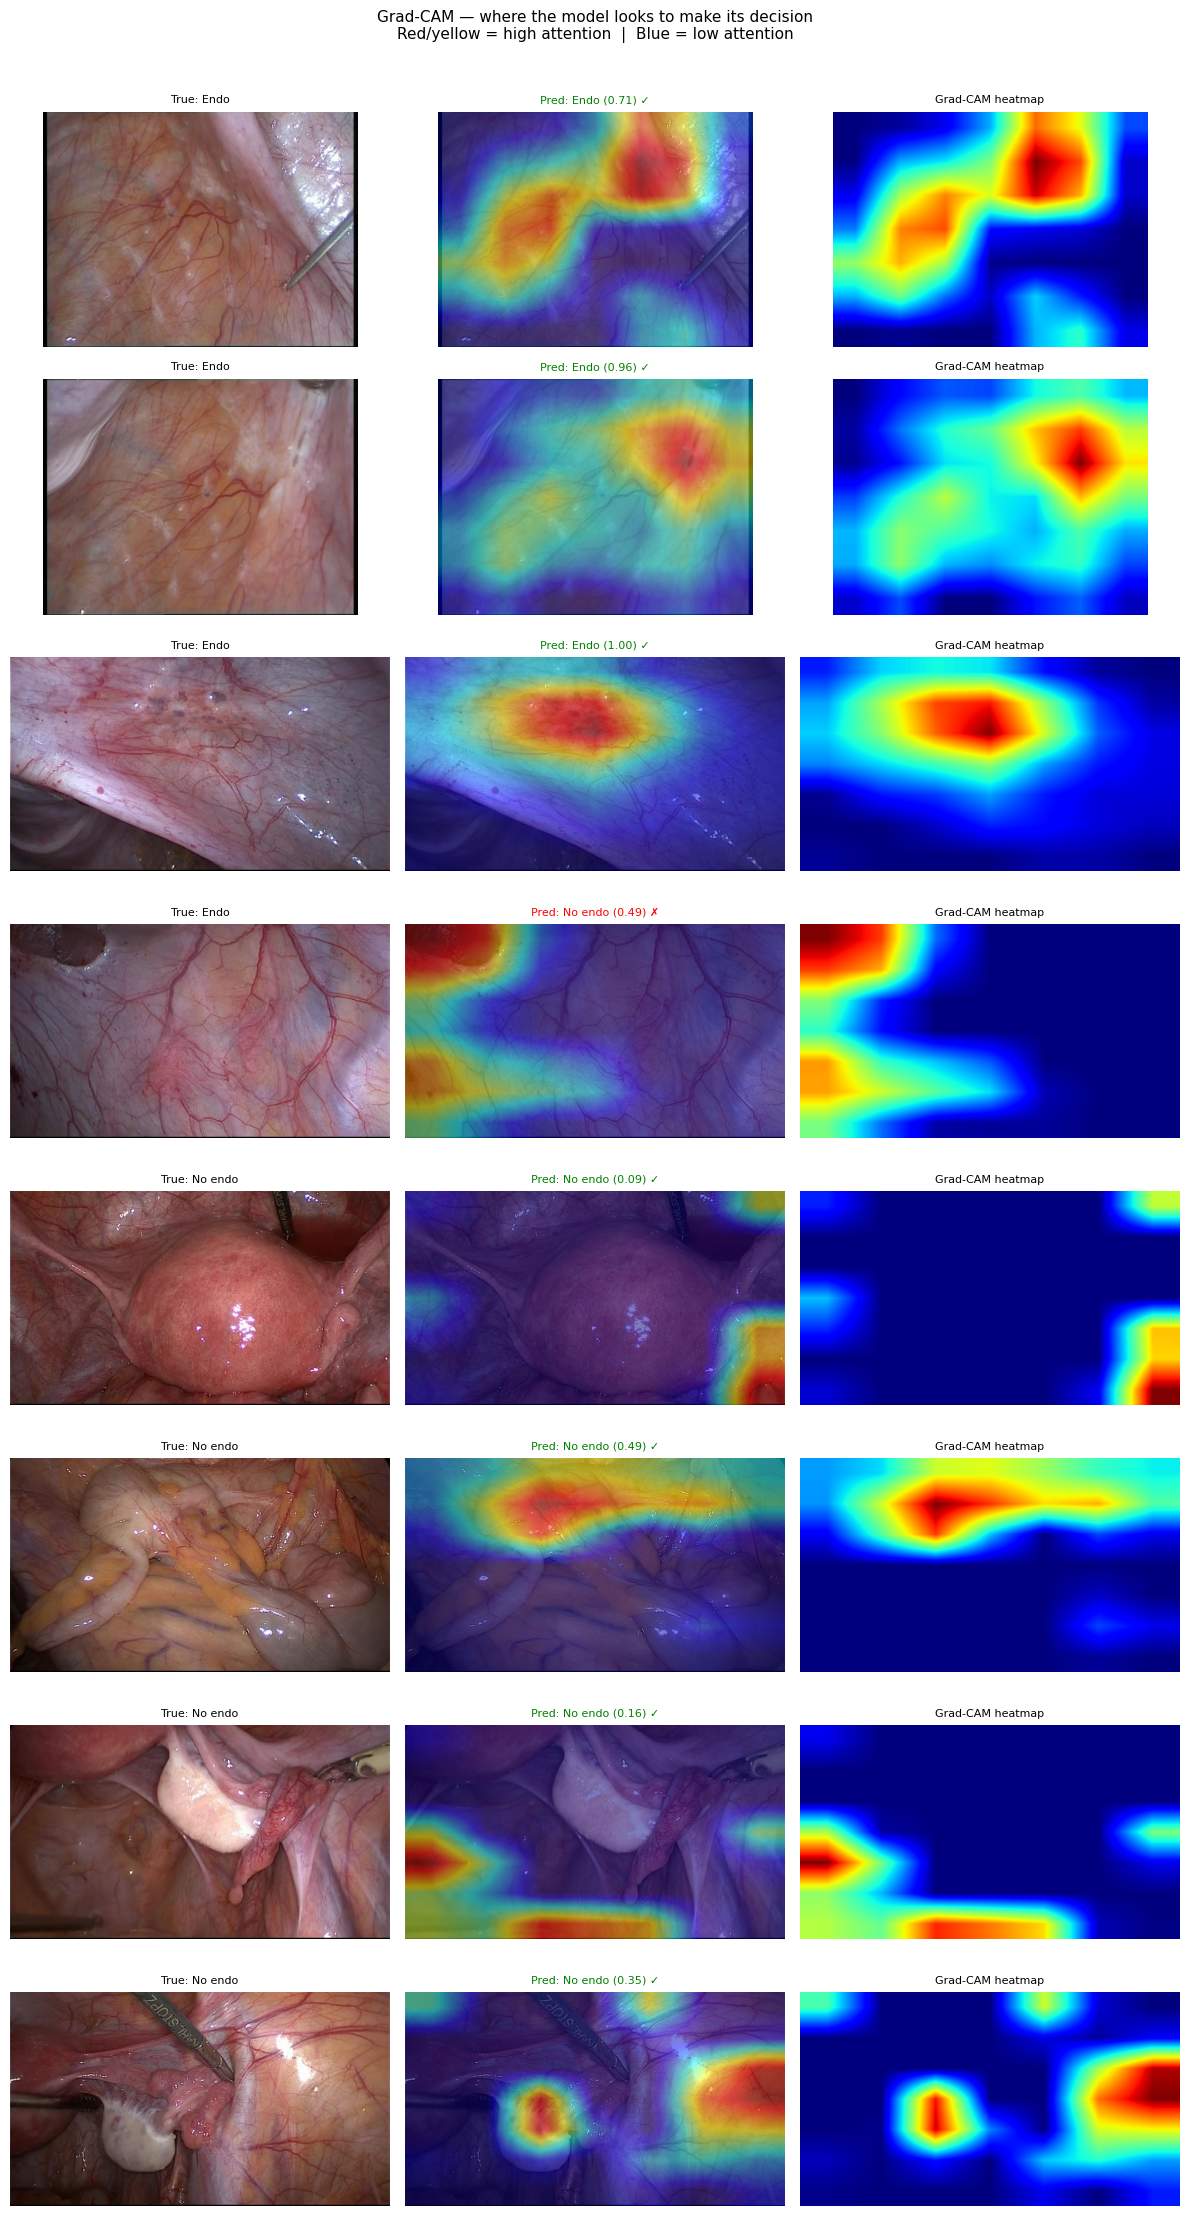

In [50]:
# Cell 28 — Visualise Grad-CAM on test images
import cv2

def show_gradcam(img_path, label, gradcam, ax_row):
    """Render raw image, heatmap overlay, and prediction on one row."""

    # Load and preprocess
    raw_img = np.array(Image.open(img_path).convert('RGB'))
    result  = val_transform(image=raw_img)
    tensor  = result['image']

    # Generate heatmap
    prob, cam = gradcam.generate(tensor)
    pred_label = 'Endo' if prob > 0.5 else 'No endo'
    true_label = 'Endo' if label == 1.0 else 'No endo'
    correct    = pred_label == true_label

    # Resize cam to image size
    cam_resized = cv2.resize(cam, (raw_img.shape[1], raw_img.shape[0]))

    # Apply colormap
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_resized), cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Blend with original
    overlay = (0.5 * raw_img + 0.5 * heatmap).astype(np.uint8)

    # Plot
    ax_row[0].imshow(raw_img)
    ax_row[0].set_title(f'True: {true_label}', fontsize=8)
    ax_row[0].axis('off')

    ax_row[1].imshow(overlay)
    status = '✓' if correct else '✗'
    color  = 'green' if correct else 'red'
    ax_row[1].set_title(
        f'Pred: {pred_label} ({prob:.2f}) {status}',
        fontsize=8, color=color
    )
    ax_row[1].axis('off')

    ax_row[2].imshow(cam_resized, cmap='jet')
    ax_row[2].set_title('Grad-CAM heatmap', fontsize=8)
    ax_row[2].axis('off')


# Pick 4 positives + 4 negatives from test set
test_pos = [(s[0], s[1]) for s in test_dataset.samples if s[1] == 1.0][:4]
test_neg = [(s[0], s[1]) for s in test_dataset.samples if s[1] == 0.0][:4]
test_samples = test_pos + test_neg

fig, axes = plt.subplots(8, 3, figsize=(12, 22))

for row, (img_path, label) in enumerate(test_samples):
    show_gradcam(img_path, label, gradcam, axes[row])

# Row labels
for row, (_, label) in enumerate(test_samples):
    axes[row][0].set_ylabel(
        'POSITIVE' if label == 1.0 else 'NEGATIVE',
        fontsize=8, rotation=90, labelpad=5,
        color='coral' if label == 1.0 else 'steelblue'
    )

plt.suptitle(
    'Grad-CAM — where the model looks to make its decision\n'
    'Red/yellow = high attention  |  Blue = low attention',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()

In [51]:
# Cell 29 — Save Grad-CAM heatmaps for explanation layer

GRADCAM_DIR = Path('./outputs/gradcam_samples')
GRADCAM_DIR.mkdir(exist_ok=True)

def save_gradcam_output(img_path, label, gradcam, save_path):
    raw_img = np.array(Image.open(img_path).convert('RGB'))
    result  = val_transform(image=raw_img)
    tensor  = result['image']

    prob, cam    = gradcam.generate(tensor)
    cam_resized  = cv2.resize(cam, (raw_img.shape[1], raw_img.shape[0]))
    heatmap      = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap      = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay      = (0.5 * raw_img + 0.5 * heatmap).astype(np.uint8)

    Image.fromarray(overlay).save(save_path)
    return prob, cam_resized

# Save 10 samples — mix of pos and neg
samples = (
    [(s[0], s[1]) for s in test_dataset.samples if s[1] == 1.0][:5] +
    [(s[0], s[1]) for s in test_dataset.samples if s[1] == 0.0][:5]
)

saved = []
for i, (img_path, label) in enumerate(samples):
    save_path = GRADCAM_DIR / f'gradcam_{i}_{"pos" if label==1 else "neg"}.jpg'
    prob, cam = save_gradcam_output(img_path, label, gradcam, save_path)
    saved.append({
        'path'      : str(save_path),
        'img_path'  : str(img_path),
        'label'     : int(label),
        'prob'      : round(prob, 4),
        'pred'      : 1 if prob > 0.5 else 0
    })
    print(f'Saved: {save_path.name}  prob={prob:.3f}')

# Save metadata for Claude layer
import json
with open('./outputs/gradcam_metadata.json', 'w') as f:
    json.dump(saved, f, indent=2)

print(f'\n{len(saved)} Grad-CAM outputs saved')
print('Metadata saved → ./outputs/gradcam_metadata.json')

Saved: gradcam_0_pos.jpg  prob=0.707
Saved: gradcam_1_pos.jpg  prob=0.960
Saved: gradcam_2_pos.jpg  prob=1.000
Saved: gradcam_3_pos.jpg  prob=0.489
Saved: gradcam_4_pos.jpg  prob=0.676
Saved: gradcam_5_neg.jpg  prob=0.089
Saved: gradcam_6_neg.jpg  prob=0.495
Saved: gradcam_7_neg.jpg  prob=0.162
Saved: gradcam_8_neg.jpg  prob=0.349
Saved: gradcam_9_neg.jpg  prob=0.267

10 Grad-CAM outputs saved
Metadata saved → ./outputs/gradcam_metadata.json


In [54]:
!pip install anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 263.7 kB/s  0:00:05 eta 0:00:01
  Attempting uninstall: idna━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/8 [jiter]o]
    Found existing installation: idna 3.11━━━━━━━━━━━━━━━━━━━━ 2/8 [jiter]
    Uninstalling idna-3.11:m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/8 [jiter]
      Successfully uninstalled idna-3.11━━━━━━━━━━━━━━━━━━━━━━ 2/8 [jiter]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [anthropic]/8 [anthropic]parser]


In [57]:
!pip install google-generativeai -q

In [59]:
# Fix — list available models first then pick the right one
import google.generativeai as genai

for m in genai.list_models():
    if 'generateContent' in m.supported_generation_methods:
        print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-omni-1.1-flash
models/gemini-3.5-transcribe
models/gemini-3.6-flash
models/gemini-3.7-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-2-preview
models/gemin

In [ ]:
# Cell 30b — Claude explanation layer using Gemini instead
import google.generativeai as genai
import base64
import json
from pathlib import Path

# Set your Gemini API key
# Get it free from: https://aistudio.google.com/app/apikey
genai.configure(api_key='AQ.Ab8RN6I-VPQsxDhEMgugGyx1qJ9wDwKCceLPnUirPbGgtBdmTw')

model_gemini = genai.GenerativeModel('gemini-3.6-flash')

def get_gemini_explanation(img_path, prob, cam, label=None):
    """
    Send the Grad-CAM overlay + prediction to Gemini
    and get a plain-English patient explanation back.
    """
    region_desc, confidence = describe_gradcam_region(cam, prob)
    prediction = 'endometriosis tissue detected' if prob > 0.5 else 'no endometriosis detected'

    # Load image for Gemini
    img = Image.open(img_path).convert('RGB')

    prompt = f"""You are EndoScan AI, a compassionate medical image assistant.
The image shown is a laparoscopy scan with a Grad-CAM heatmap overlay.
Red/yellow areas show where the AI model focused its attention.
Blue areas show regions the model largely ignored.

AI model findings:
- Result: {prediction}
- Confidence: {confidence} ({prob*100:.0f}%)
- Model focused most on: the {region_desc} area of the image

Please write a warm, plain-English explanation of these findings for a patient
with no medical background. Follow these rules:
- 3-4 short paragraphs, calm and reassuring tone
- Explain what the highlighted areas mean in simple terms
- Never use jargon without explaining it immediately
- Be honest but gentle if endo is detected
- Always remind them this is an AI screening tool, not a diagnosis
- Encourage them to discuss results with their gynaecologist

Write only the explanation, nothing else."""

    response = model_gemini.generate_content([img, prompt])
    return response.text


# ── Test on 3 samples ─────────────────────────────────────────────
print('=' * 60)
print('  GEMINI EXPLANATION LAYER — SAMPLE OUTPUTS')
print('=' * 60)

for sample in samples[:3]:
    print(f"\n{'─'*60}")
    print(f"Image  : {Path(sample['img_path']).name}")
    print(f"Label  : {'Endo' if sample['label'] == 1 else 'No endo'}")
    print(f"Prob   : {sample['prob']}")
    print(f"Pred   : {'Endo' if sample['pred'] == 1 else 'No endo'}")
    print(f"{'─'*60}")

    raw_img = np.array(Image.open(sample['img_path']).convert('RGB'))
    tensor  = val_transform(image=raw_img)['image']
    prob, cam = gradcam.generate(tensor)

    explanation = get_gemini_explanation(sample['path'], prob, cam, sample['label'])
    print(explanation)
    print()

  GEMINI EXPLANATION LAYER — SAMPLE OUTPUTS

────────────────────────────────────────────────────────────
Image  : c_102_v_(video_3119.mp4)_f_1311.jpg
Label  : Endo
Prob   : 0.707
Pred   : Endo
────────────────────────────────────────────────────────────


NotFound: 404 This model models/gemini-2.5-flash is no longer available to new users. Please update your code to use models/gemini-3.6-flash for the latest features and improvements. We recommend you to use the Interactions API.

In [68]:
# Cell 30c — Gemini via REST API (bypasses gRPC issues)
import requests
import base64
import json
from pathlib import Path
from PIL import Image
import io

GEMINI_API_KEY = 'AQ.Ab8RN6I-VPQsxDhEMgugGyx1qJ9wDwKCceLPnUirPbGgtBdmTw'  # use your regenerated key
GEMINI_URL = 'https://generativelanguage.googleapis.com/v1beta/models/gemini-3.6-flash:generateContent'

def get_gemini_explanation(img_path, prob, cam, label=None):
    region_desc, confidence = describe_gradcam_region(cam, prob)
    prediction = 'endometriosis tissue detected' if prob > 0.5 else 'no endometriosis detected'

    # Encode image as base64
    img = Image.open(img_path).convert('RGB')
    buf = io.BytesIO()
    img.save(buf, format='JPEG')
    img_b64 = base64.b64encode(buf.getvalue()).decode('utf-8')

    prompt = f"""You are EndoScan AI, a compassionate medical image assistant.
The image shown is a laparoscopy scan with a Grad-CAM heatmap overlay.
Red/yellow areas show where the AI model focused its attention.
Blue areas show regions the model largely ignored.

AI model findings:
- Result: {prediction}
- Confidence: {confidence} ({prob*100:.0f}%)
- Model focused most on: the {region_desc} area of the image

Please write a warm, plain-English explanation of these findings for a patient
with no medical background. Follow these rules:
- 3-4 short paragraphs, calm and reassuring tone
- Explain what the highlighted areas mean in simple terms
- Never use jargon without immediately explaining it
- Be honest but gentle if endo is detected
- Always remind them this is an AI screening tool, not a diagnosis
- Encourage them to discuss results with their gynaecologist

Write only the explanation, nothing else."""

    payload = {
        'contents': [{
            'parts': [
                {
                    'inline_data': {
                        'mime_type': 'image/jpeg',
                        'data'     : img_b64
                    }
                },
                {'text': prompt}
            ]
        }],
        'generationConfig': {
            'maxOutputTokens': 2048,  # was 500
            'temperature'    : 0.7
}
    }

    response = requests.post(
        f'{GEMINI_URL}?key={GEMINI_API_KEY}',
        headers={'Content-Type': 'application/json'},
        json=payload
    )

    if response.status_code == 200:
        return response.json()['candidates'][0]['content']['parts'][0]['text']
    else:
        return f'Error {response.status_code}: {response.json()}'


# ── Test on 3 samples ─────────────────────────────────────────────
print('=' * 60)
print('  GEMINI EXPLANATION LAYER — SAMPLE OUTPUTS')
print('=' * 60)

for sample in samples[:3]:
    print(f"\n{'─'*60}")
    print(f"Image : {Path(sample['img_path']).name}")
    print(f"Label : {'Endo' if sample['label'] == 1 else 'No endo'}")
    print(f"Prob  : {sample['prob']}")
    print(f"{'─'*60}")

    raw_img = np.array(Image.open(sample['img_path']).convert('RGB'))
    tensor  = val_transform(image=raw_img)['image']
    prob, cam = gradcam.generate(tensor)

    explanation = get_gemini_explanation(sample['path'], prob, cam, sample['label'])
    print(explanation)
    print()

  GEMINI EXPLANATION LAYER — SAMPLE OUTPUTS

────────────────────────────────────────────────────────────
Image : c_102_v_(video_3119.mp4)_f_1311.jpg
Label : Endo
Prob  : 0.707
────────────────────────────────────────────────────────────
This image from your laparoscopy—a keyhole procedure used to look inside the pelvic area—has been analyzed using our AI system. Based on this scan, the model detected potential signs of endometriosis tissue with a moderate confidence score of 71%. 

The bright red and yellow highlighted regions near the centre and top-right of the image show where the AI focused its attention. These warm colors mark areas where the system identified tissue patterns that may resemble endometriosis—a condition where tissue similar to the lining of the womb grows outside of it. The blue regions show areas the model largely passed over as less concerning.

Please remember that this tool is designed solely to aid in screening and highlight potential areas of interest—it doe